# Simplified dataset sampling by mode

This notebook loads one manuscript dataset and compares MIMIC synthesis diagnostics for each generation mode, first without privacy filtering and then with nearest-neighbor ambiguity filtering enabled.


In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src" / "mimic").exists() else Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
if NOTEBOOK_DIR.exists() and str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from mimic import NearestNeighborPrivacyFilter, load_paper_dataset, paper_dataset_registry
from mimic_notebook_utils import run_dataset_synthesis_diagnostics

RANDOM_STATE = 42
DATASET_KEY = "adult"  # options: "adult", "bank_marketing", "default_credit"
N_ROWS = 300
CAPACITY = 0.25
N_JOBS = -1
FEATURE_N_JOBS = -1
PRIVACY_FILTER = NearestNeighborPrivacyFilter(k=5, min_ambiguous_neighbors=2, exclude_generation_sources=False)


## Load Dataset

`DATASET_KEY` selects one of the manuscript datasets. `N_ROWS` controls the number of real rows used for each synthesis run.


In [ ]:
display(paper_dataset_registry())

df, columns = load_paper_dataset(DATASET_KEY, n_rows=N_ROWS, random_state=RANDOM_STATE)
regression_columns = columns["regression"]
classification_columns = columns["classification"]

display(df.head())
display(
    pd.DataFrame(
        {
            "quantity": ["dataset", "rows", "columns", "regression_columns", "classification_columns", "n_jobs", "feature_n_jobs"],
            "value": [DATASET_KEY, len(df), df.shape[1], len(regression_columns), len(classification_columns), N_JOBS, FEATURE_N_JOBS],
        }
    )
)
display(pd.DataFrame({"role": ["ignore", "regression", "classification"], "columns": [columns["ignore"], regression_columns, classification_columns]}))


## Mode 0: identity

This run uses the mode without nearest-neighbor ambiguity filtering.

,quantity,value
0,mode,0
1,privacy_filter,False
2,real_rows,300
3,synthetic_rows,300
4,columns_match,True


,feature,total_variation_distance,n_categories
3,occupation,0.110,13
0,workclass,0.107,7
7,native-country,0.077,22
4,relationship,0.060,6
1,education,0.057,16
2,marital-status,0.037,6
5,race,0.023,5
6,sex,0.010,2
8,label,0.003,2


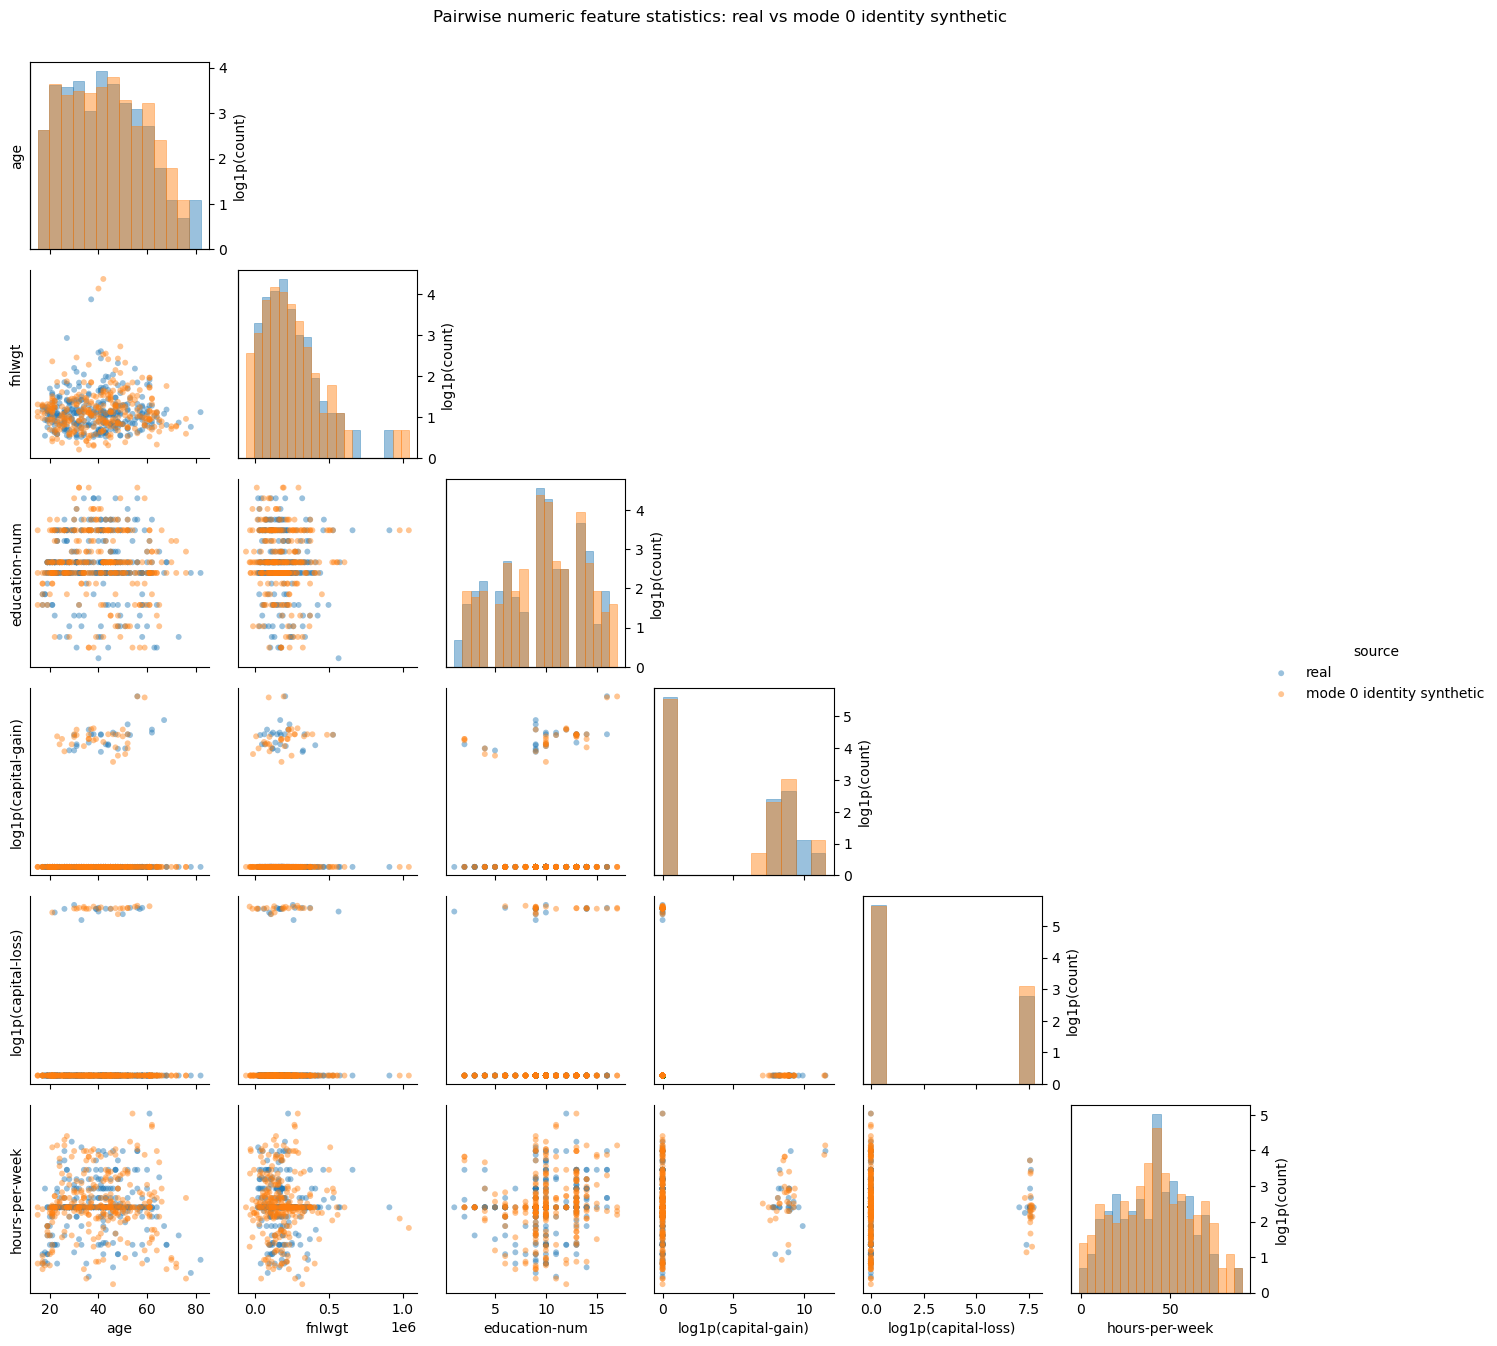

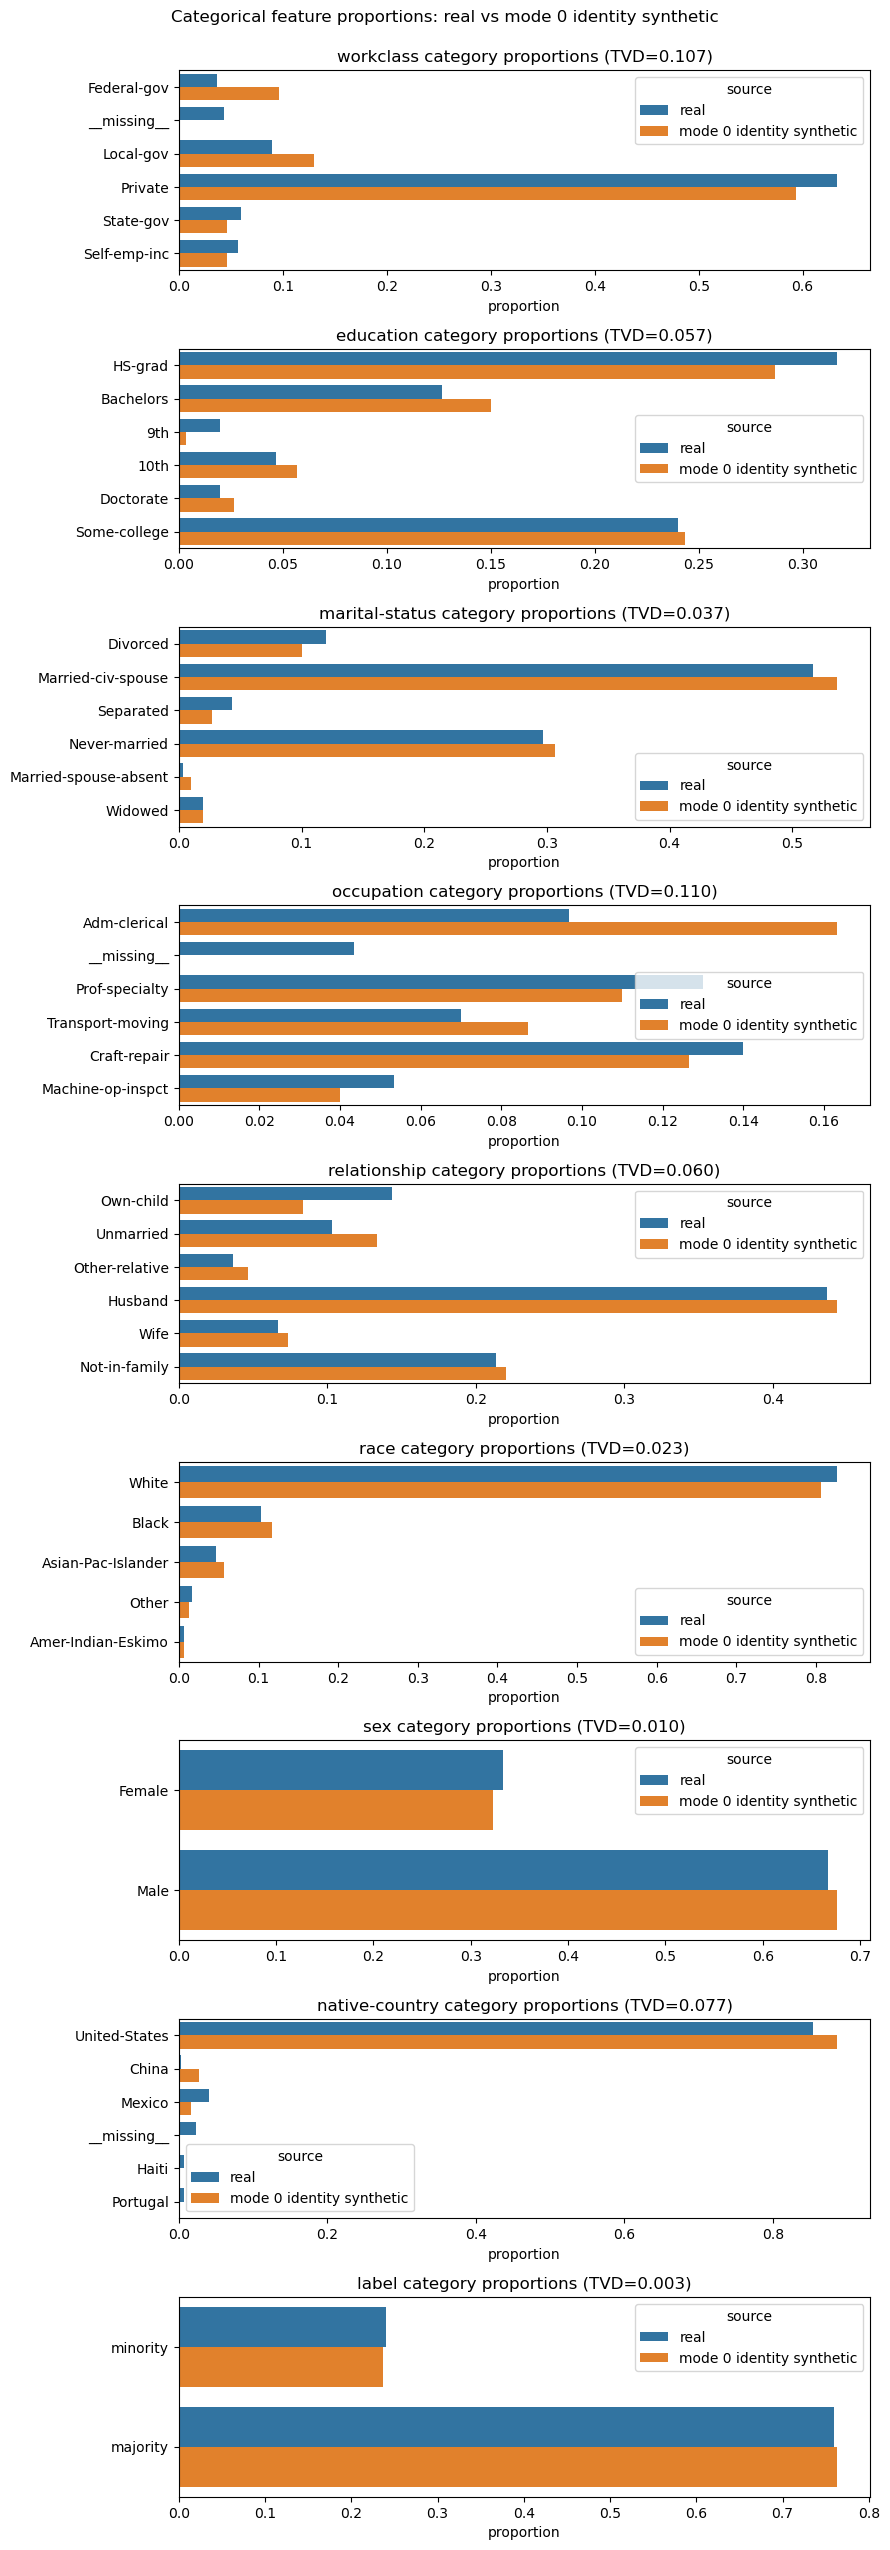

In [3]:
mode0_plain = run_dataset_synthesis_diagnostics(
    df,
    columns=columns,
    mode=0,
    capacity=0.0,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    feature_n_jobs=FEATURE_N_JOBS,
    privacy_filter=None,
    label="mode 0 identity synthetic",
)

display(mode0_plain["summary"].style.set_caption("Mode 0 summary"))
display(
    mode0_plain["categorical_summary"].sort_values("total_variation_distance", ascending=False)
    .style.format({"total_variation_distance": "{:.3f}"})
    .set_caption("Mode 0 categorical summary")
)


## Mode 0: identity with privacy filtering

Nearest-neighbor ambiguity filtering is enabled for this run.

/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,quantity,value
0,mode,0
1,privacy_filter,True
2,real_rows,300
3,synthetic_rows,300
4,columns_match,True


,feature,total_variation_distance,n_categories
1,education,0.203,16
4,relationship,0.183,6
3,occupation,0.167,13
2,marital-status,0.150,6
0,workclass,0.147,7
5,race,0.127,5
7,native-country,0.127,22
6,sex,0.070,2
8,label,0.027,2


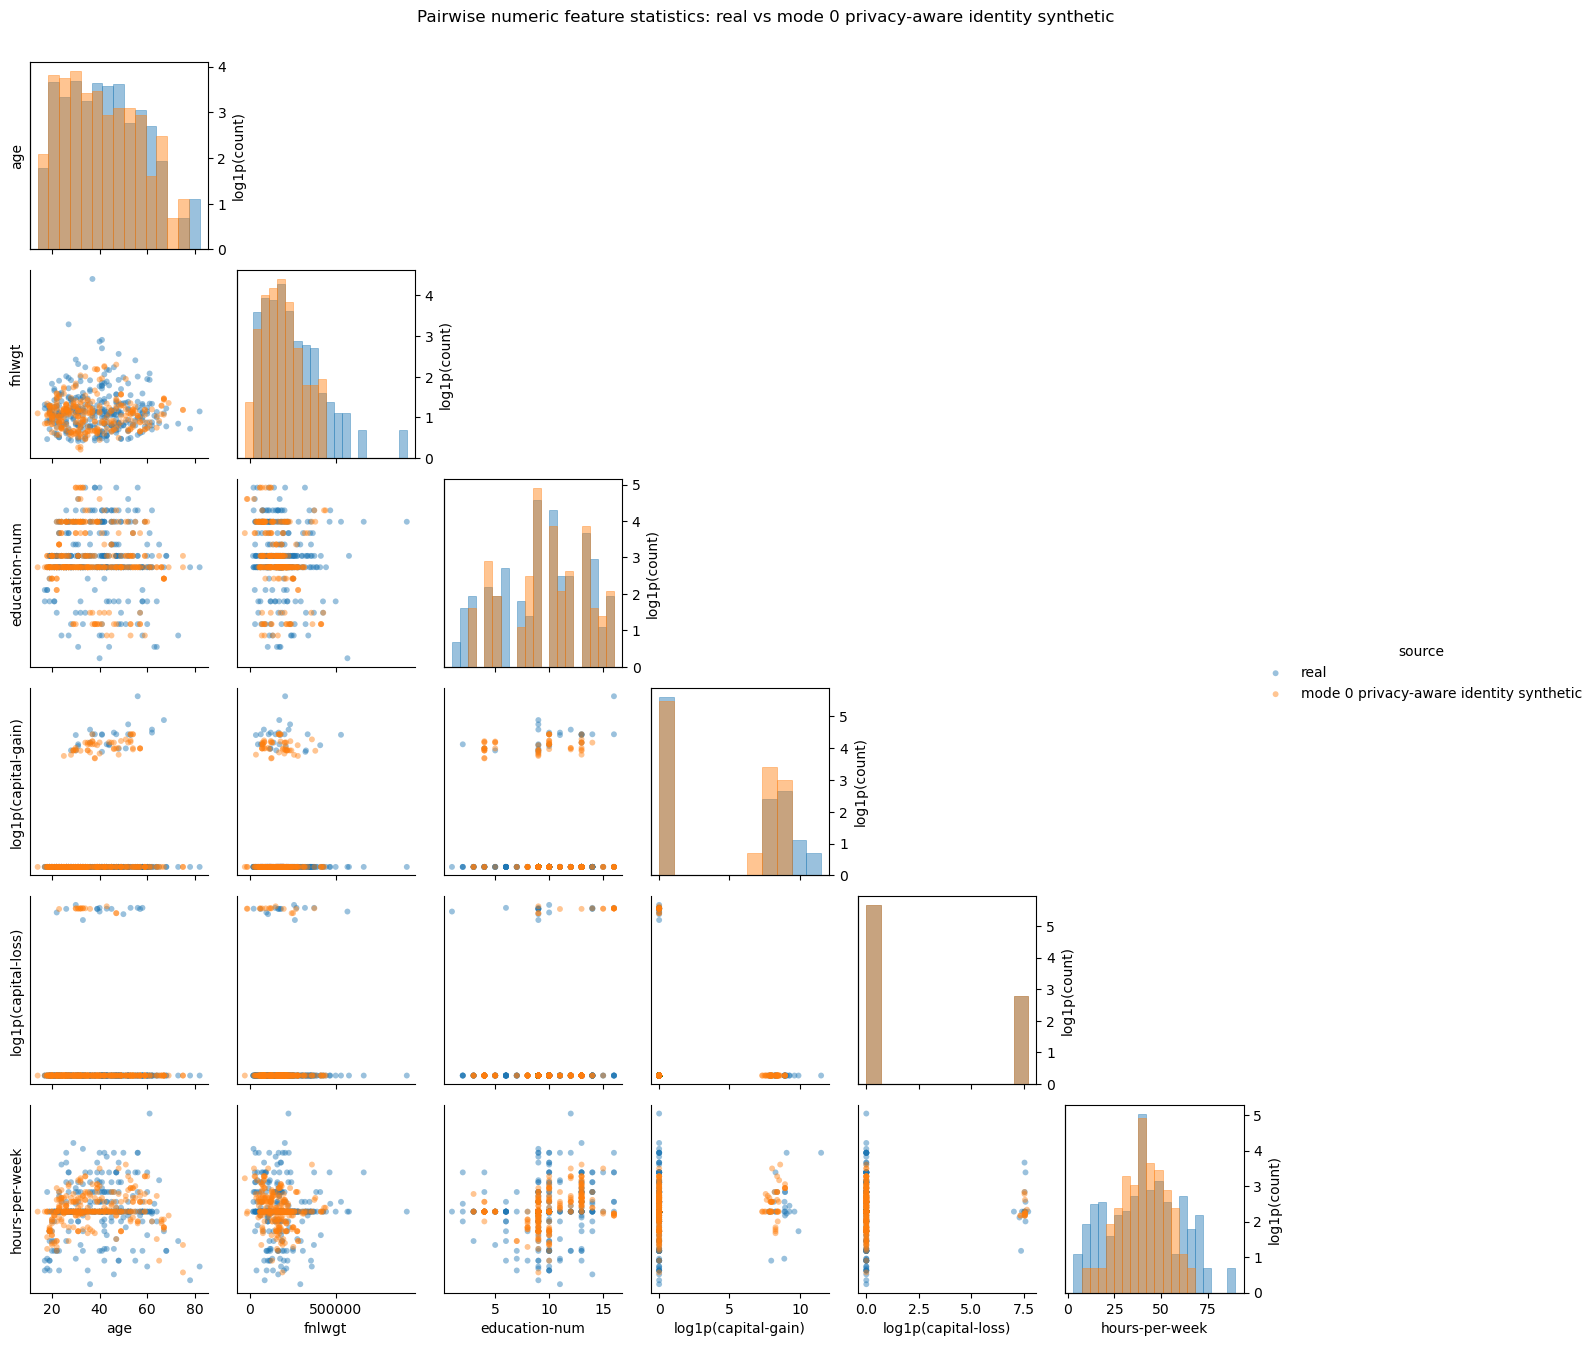

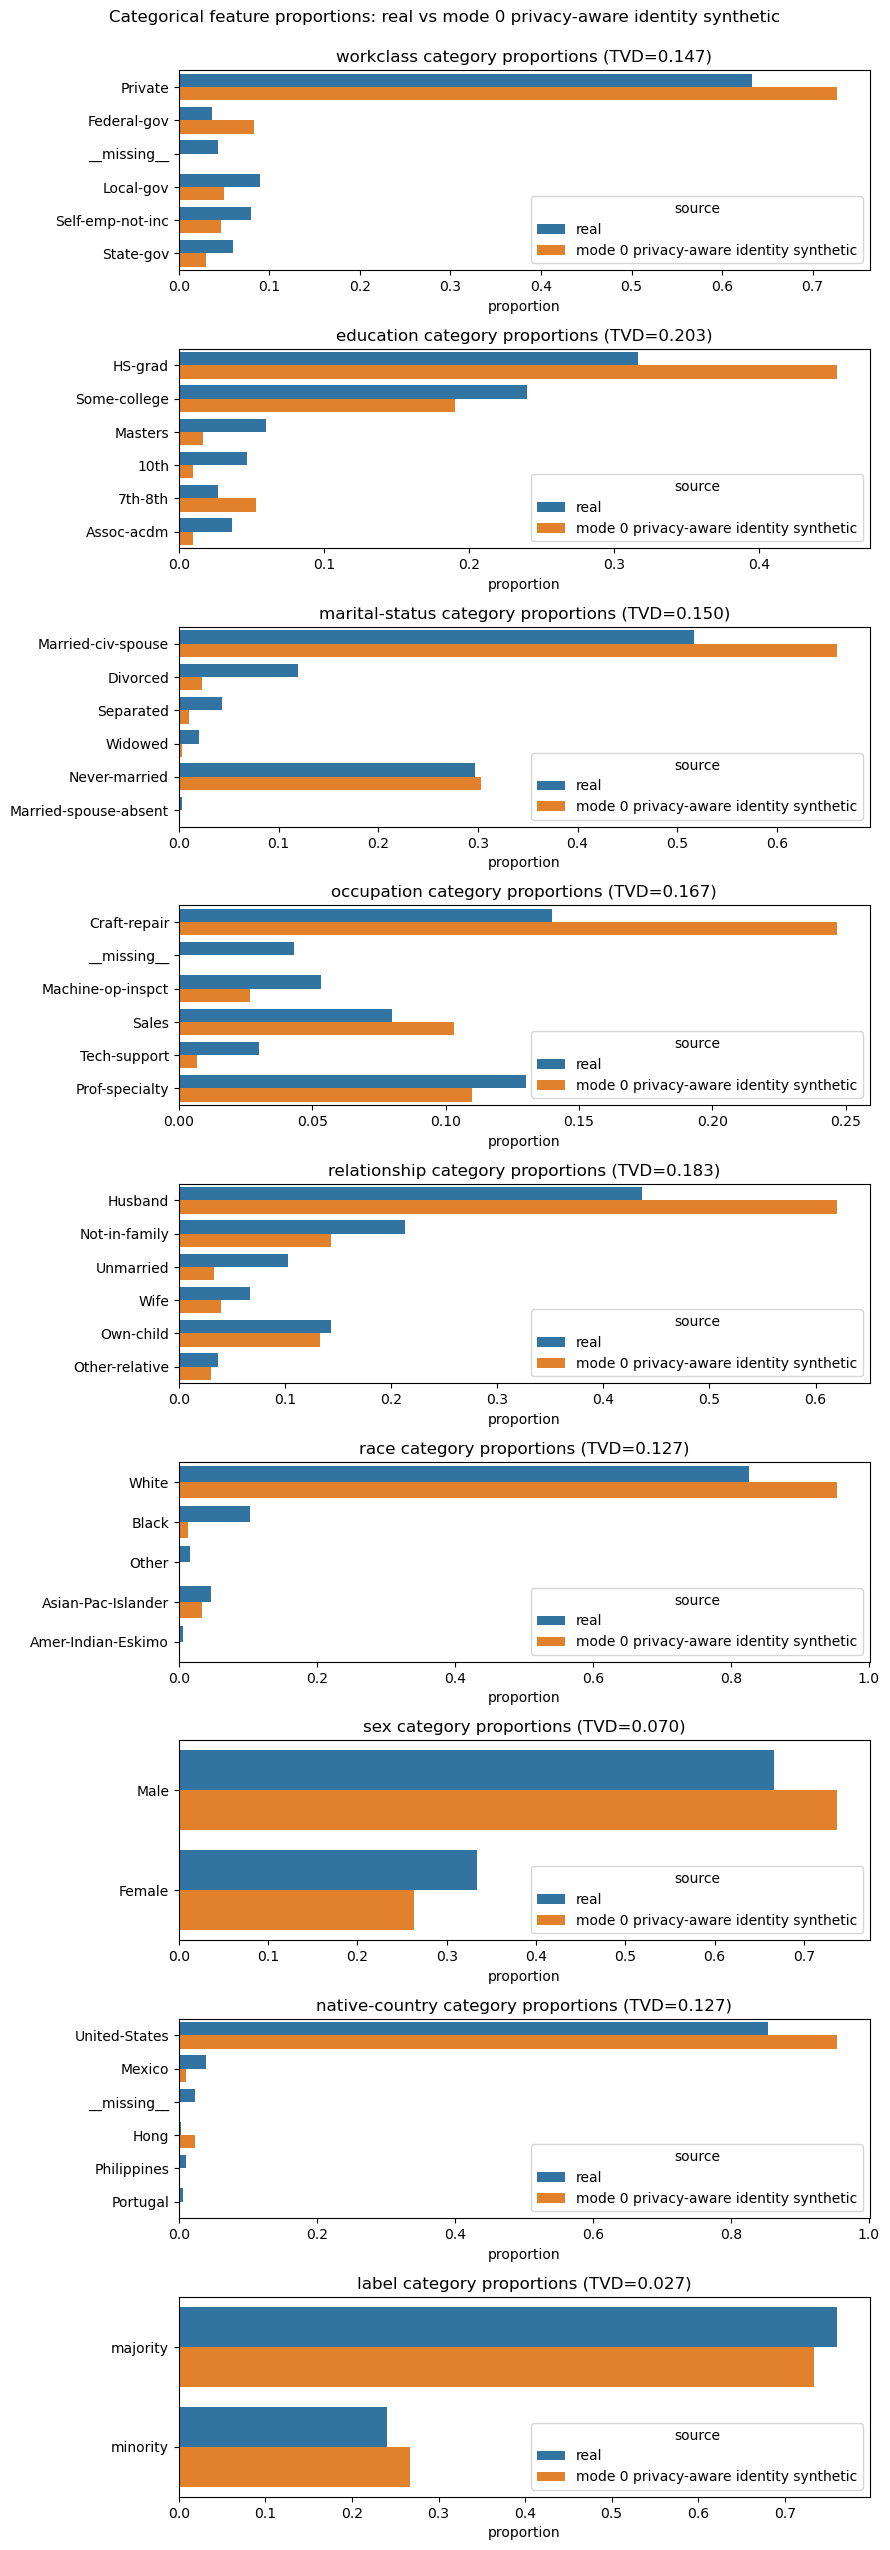

In [4]:
mode0_private = run_dataset_synthesis_diagnostics(
    df,
    columns=columns,
    mode=0,
    capacity=0.0,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    feature_n_jobs=FEATURE_N_JOBS,
    privacy_filter=PRIVACY_FILTER,
    label="mode 0 privacy-aware identity synthetic",
)

display(mode0_private["summary"].style.set_caption("Mode 0 privacy-aware summary"))
display(
    mode0_private["categorical_summary"].sort_values("total_variation_distance", ascending=False)
    .style.format({"total_variation_distance": "{:.3f}"})
    .set_caption("Mode 0 privacy-aware categorical summary")
)


## Mode 1: direct

This run uses the mode without nearest-neighbor ambiguity filtering.

,quantity,value
0,mode,1
1,privacy_filter,False
2,real_rows,300
3,synthetic_rows,300
4,columns_match,True


,feature,total_variation_distance,n_categories
1,education,0.390,16
3,occupation,0.373,13
0,workclass,0.367,7
5,race,0.167,5
7,native-country,0.147,22
8,label,0.087,2
2,marital-status,0.083,6
4,relationship,0.080,6
6,sex,0.043,2


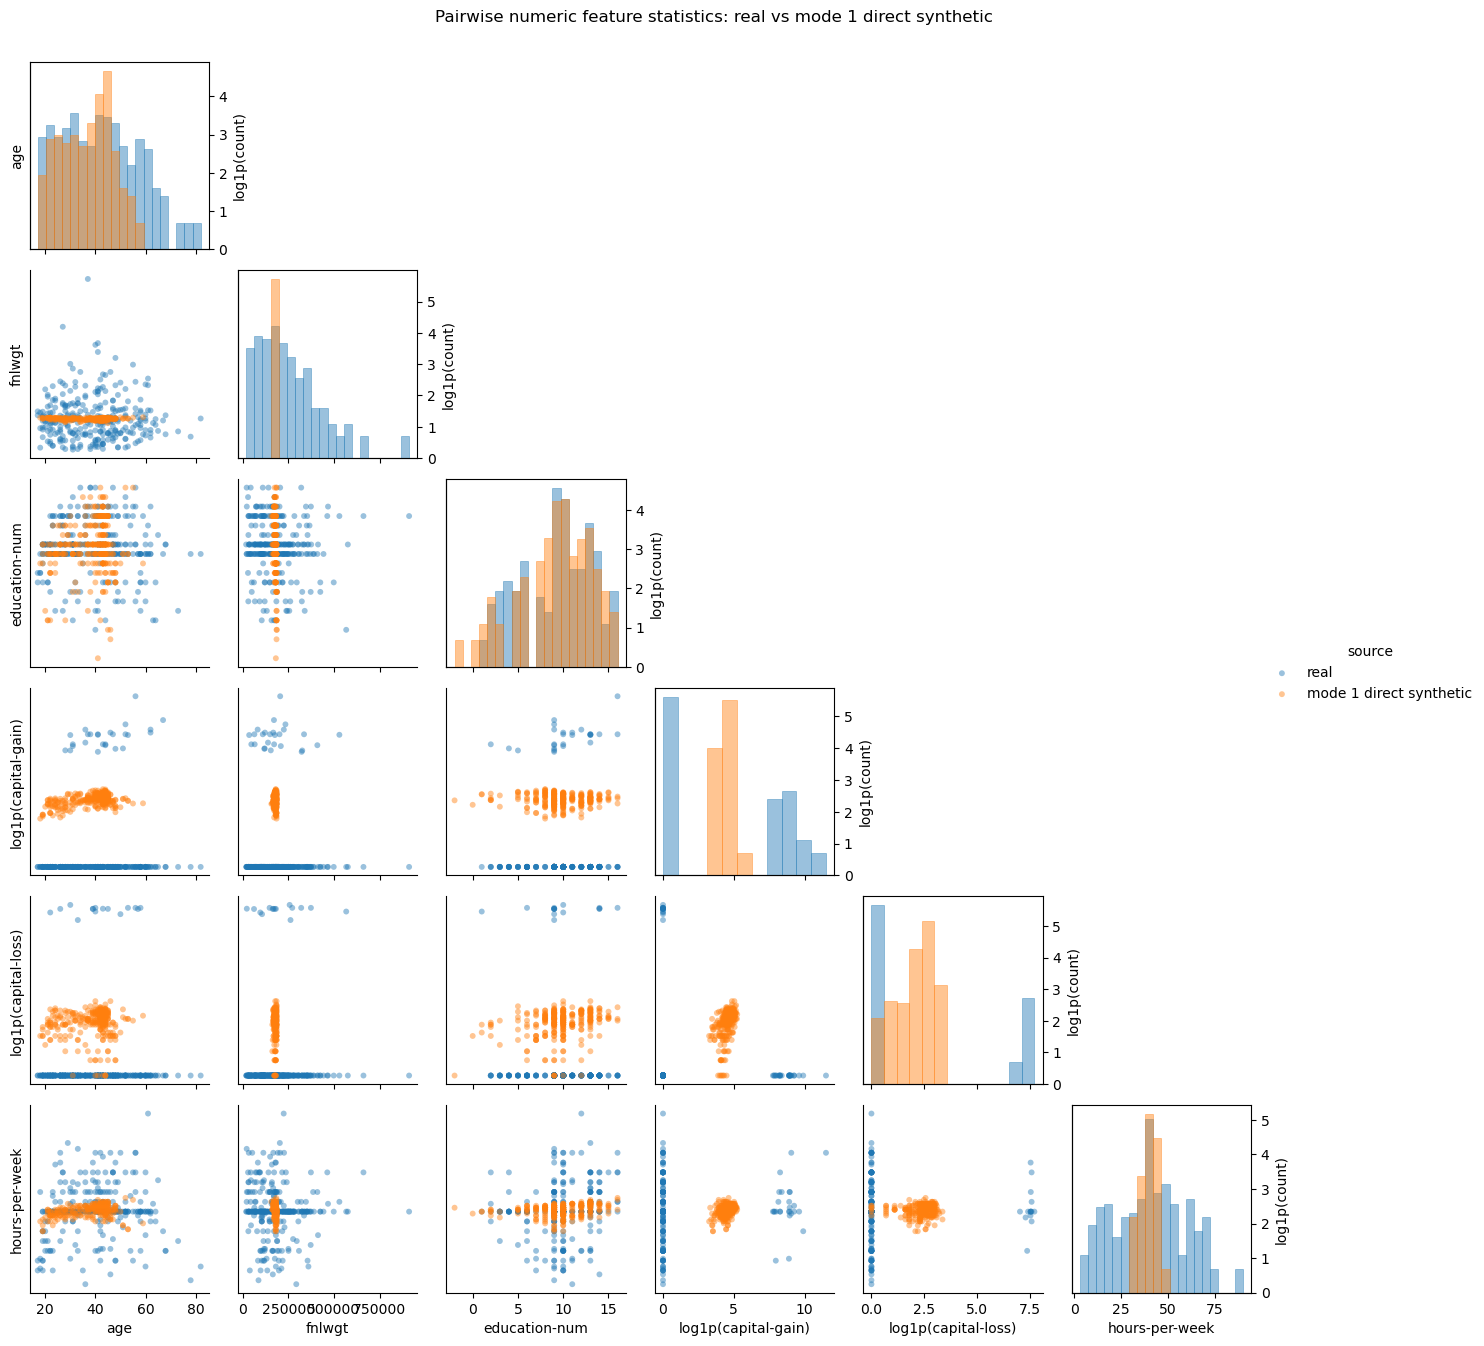

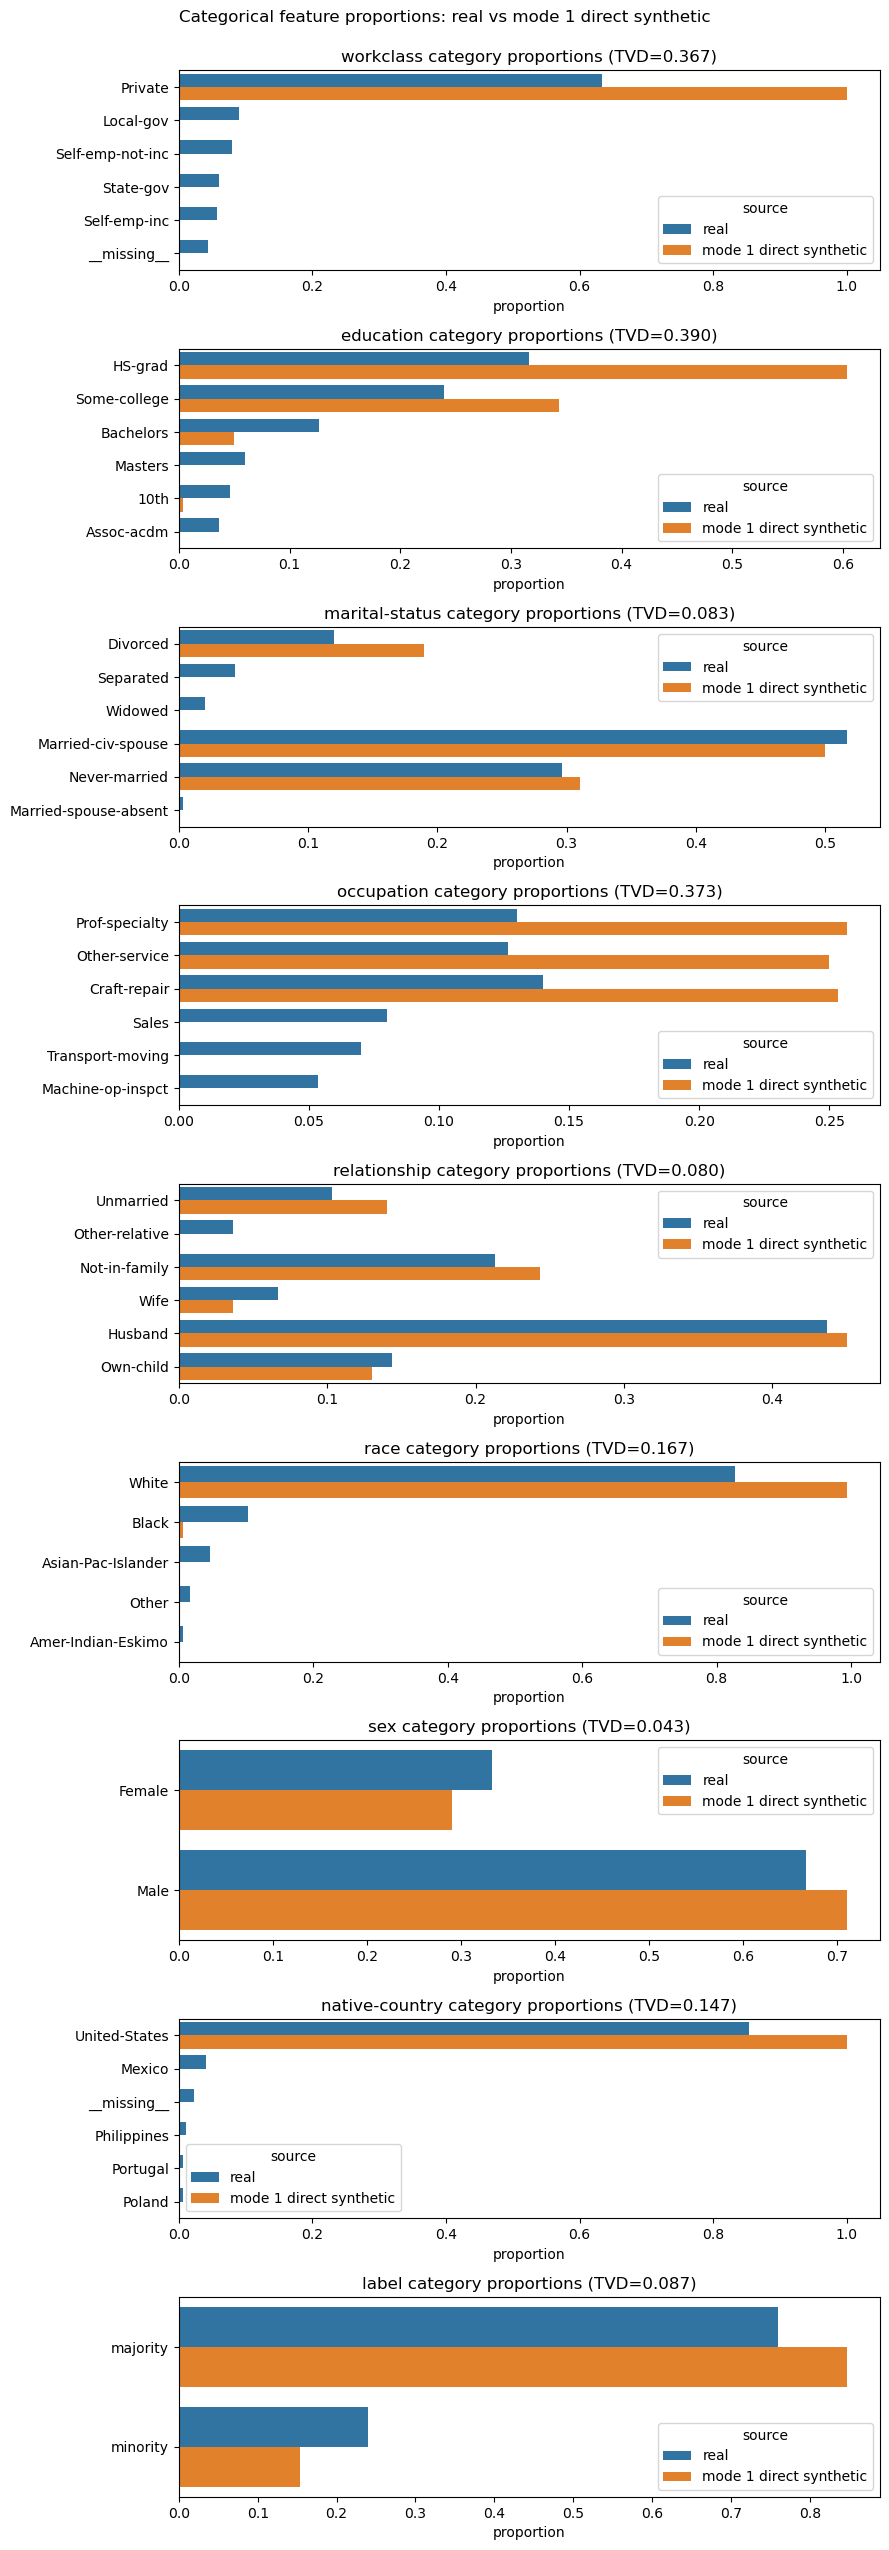

In [5]:
mode1_plain = run_dataset_synthesis_diagnostics(
    df,
    columns=columns,
    mode=1,
    capacity=CAPACITY,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    feature_n_jobs=FEATURE_N_JOBS,
    privacy_filter=None,
    label="mode 1 direct synthetic",
)

display(mode1_plain["summary"].style.set_caption("Mode 1 summary"))
display(
    mode1_plain["categorical_summary"].sort_values("total_variation_distance", ascending=False)
    .style.format({"total_variation_distance": "{:.3f}"})
    .set_caption("Mode 1 categorical summary")
)


## Mode 1: direct with privacy filtering

Nearest-neighbor ambiguity filtering is enabled for this run.

,quantity,value
0,mode,1
1,privacy_filter,True
2,real_rows,300
3,synthetic_rows,300
4,columns_match,True


,feature,total_variation_distance,n_categories
3,occupation,0.490,13
1,education,0.420,16
0,workclass,0.367,7
8,label,0.183,2
5,race,0.173,5
4,relationship,0.157,6
7,native-country,0.147,22
2,marital-status,0.130,6
6,sex,0.023,2


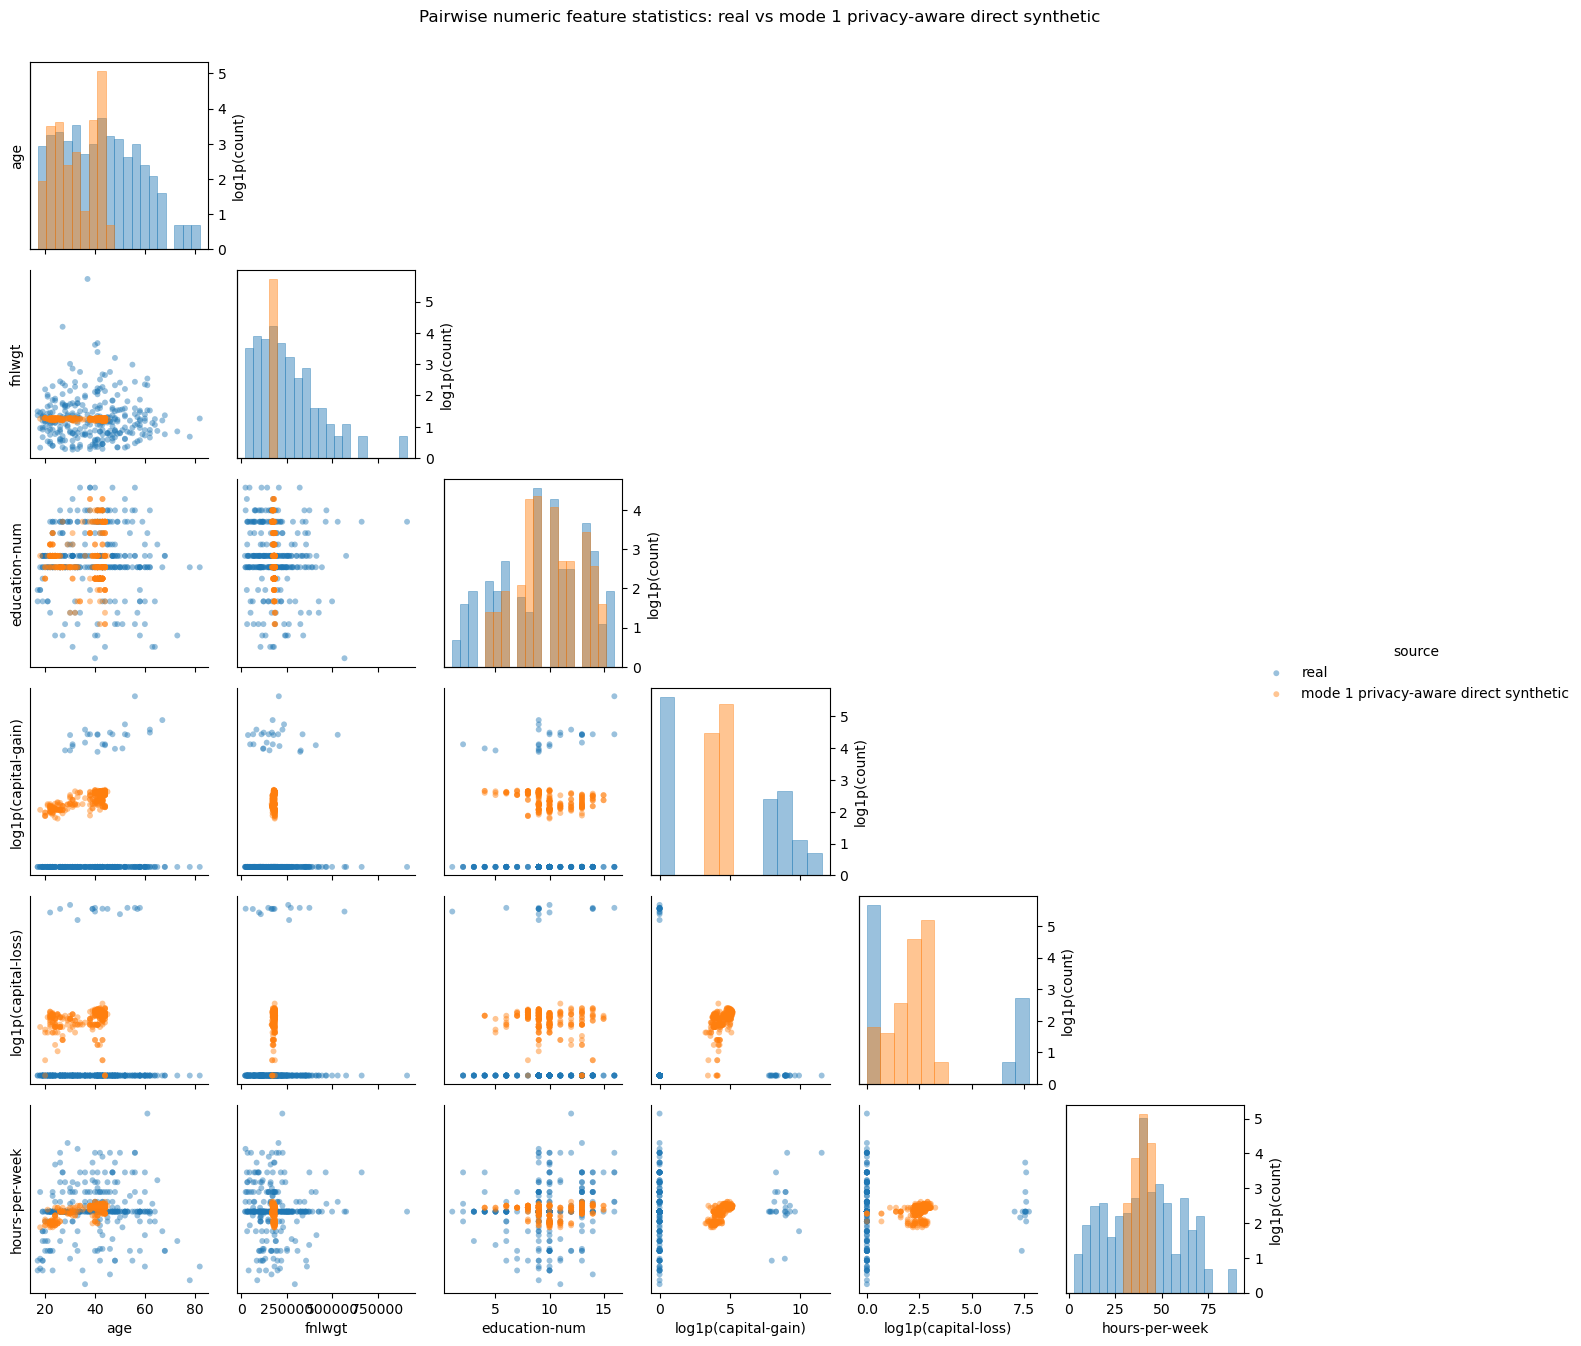

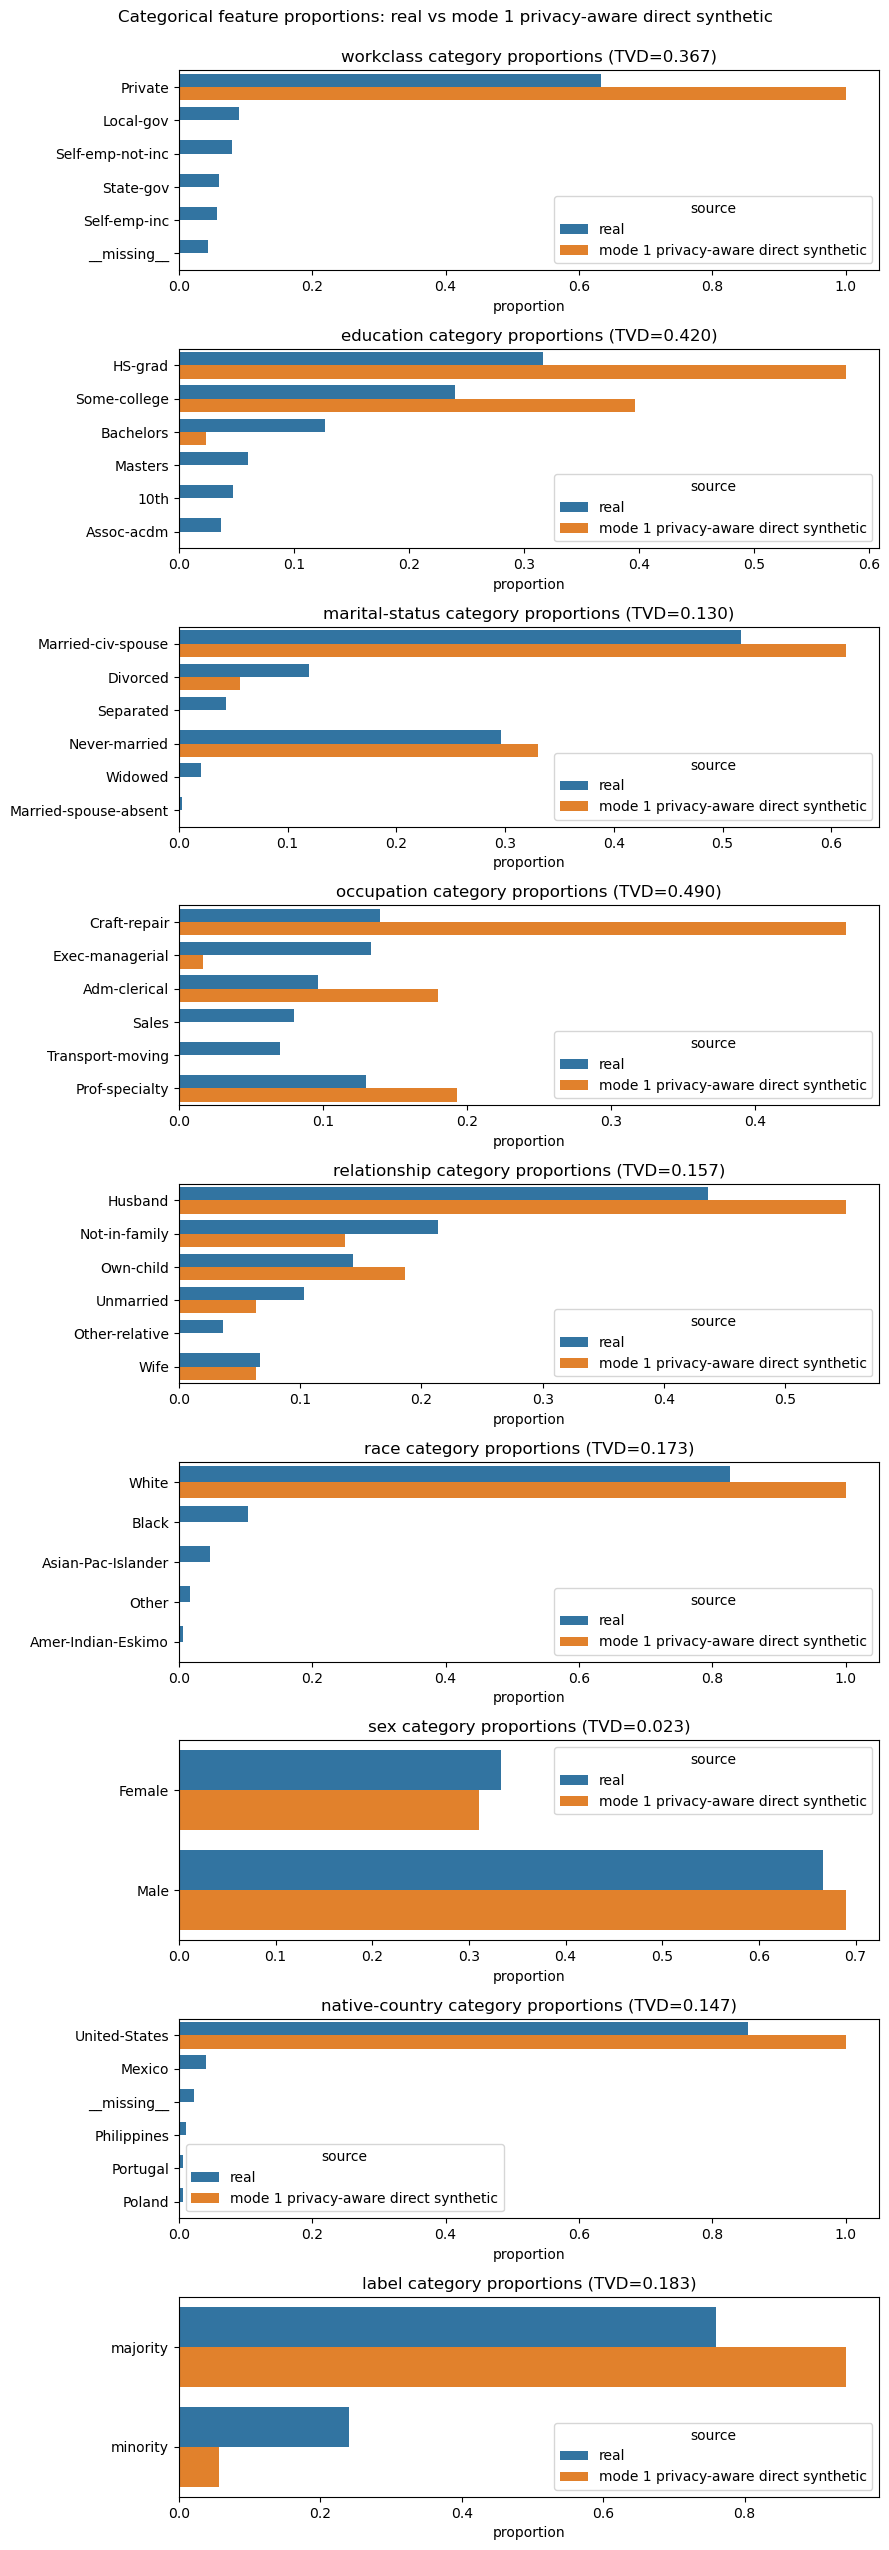

In [6]:
mode1_private = run_dataset_synthesis_diagnostics(
    df,
    columns=columns,
    mode=1,
    capacity=CAPACITY,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    feature_n_jobs=FEATURE_N_JOBS,
    privacy_filter=PRIVACY_FILTER,
    label="mode 1 privacy-aware direct synthetic",
)

display(mode1_private["summary"].style.set_caption("Mode 1 privacy-aware summary"))
display(
    mode1_private["categorical_summary"].sort_values("total_variation_distance", ascending=False)
    .style.format({"total_variation_distance": "{:.3f}"})
    .set_caption("Mode 1 privacy-aware categorical summary")
)


## Mode 2: factorised

This run uses the mode without nearest-neighbor ambiguity filtering.

,quantity,value
0,mode,2
1,privacy_filter,False
2,real_rows,300
3,synthetic_rows,300
4,columns_match,True


,feature,total_variation_distance,n_categories
0,workclass,0.093,7
1,education,0.093,16
3,occupation,0.093,13
6,sex,0.060,2
7,native-country,0.057,22
4,relationship,0.033,6
5,race,0.033,5
2,marital-status,0.030,6
8,label,0.007,2


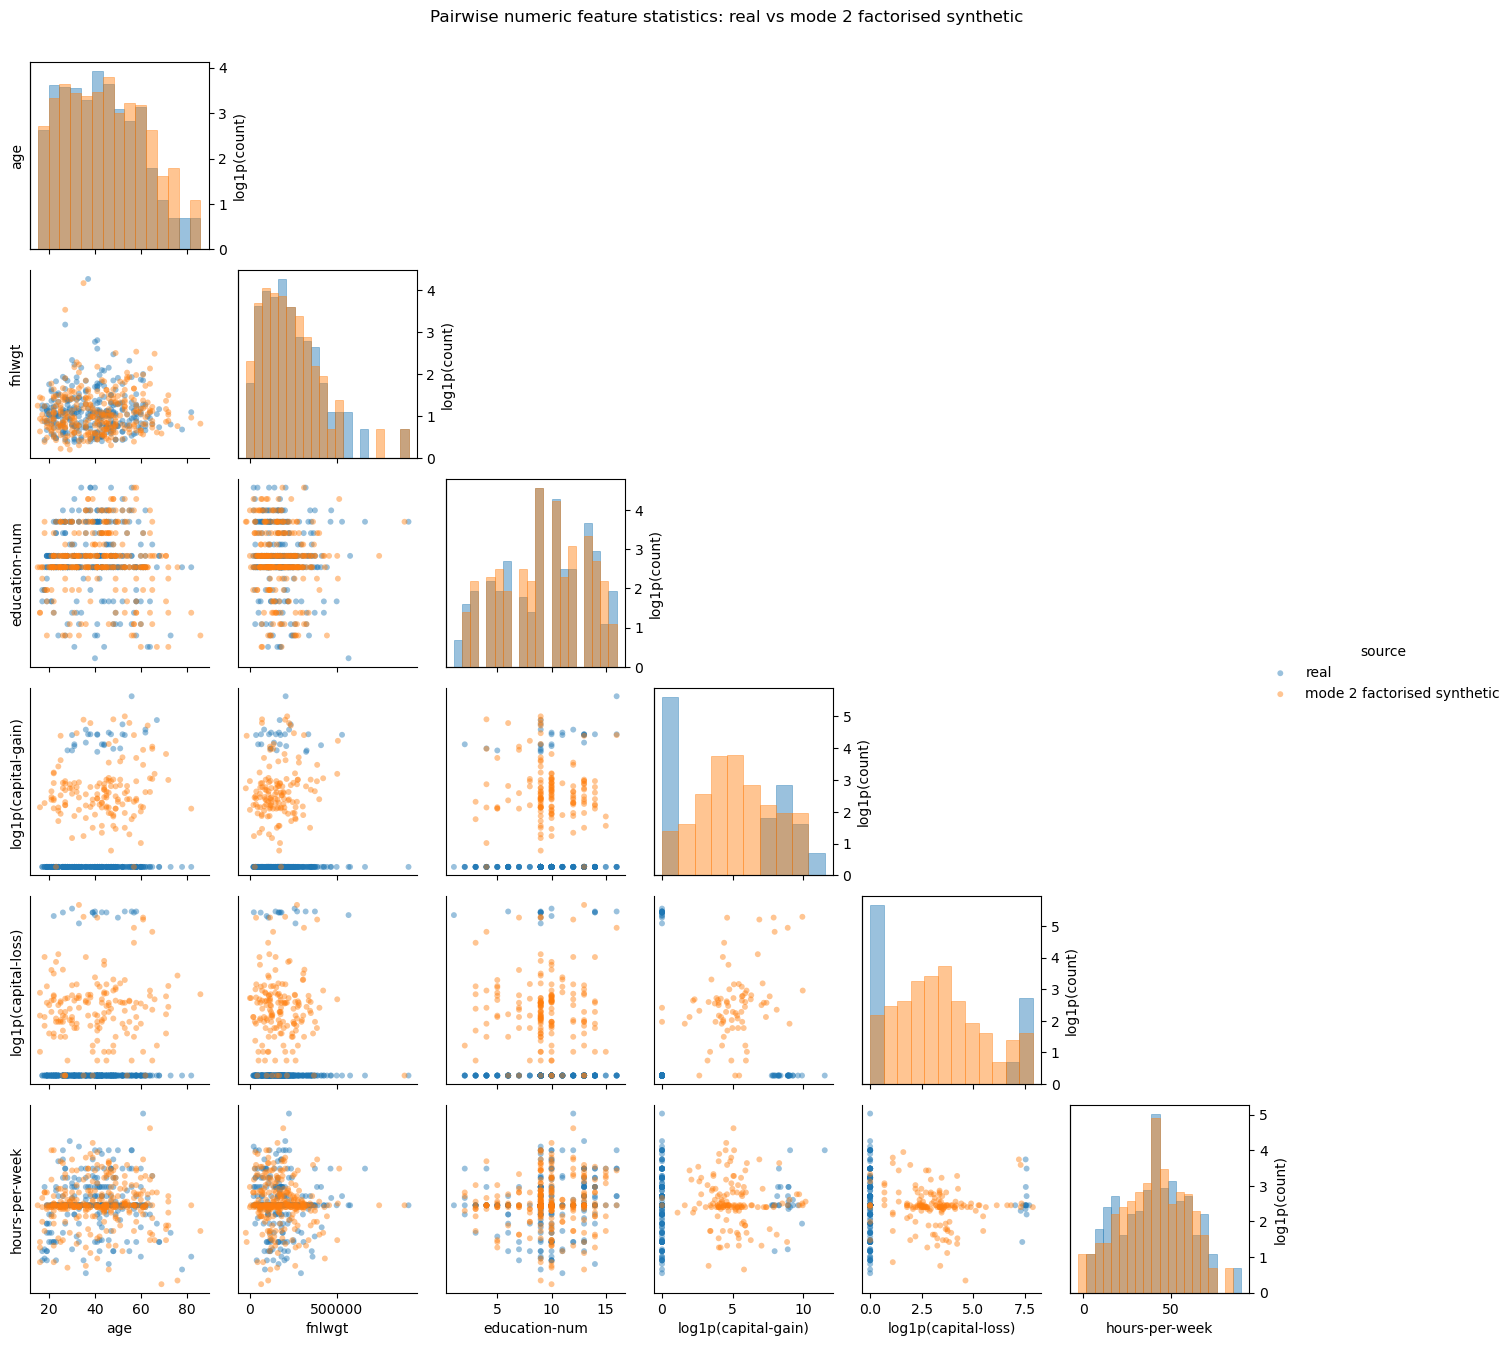

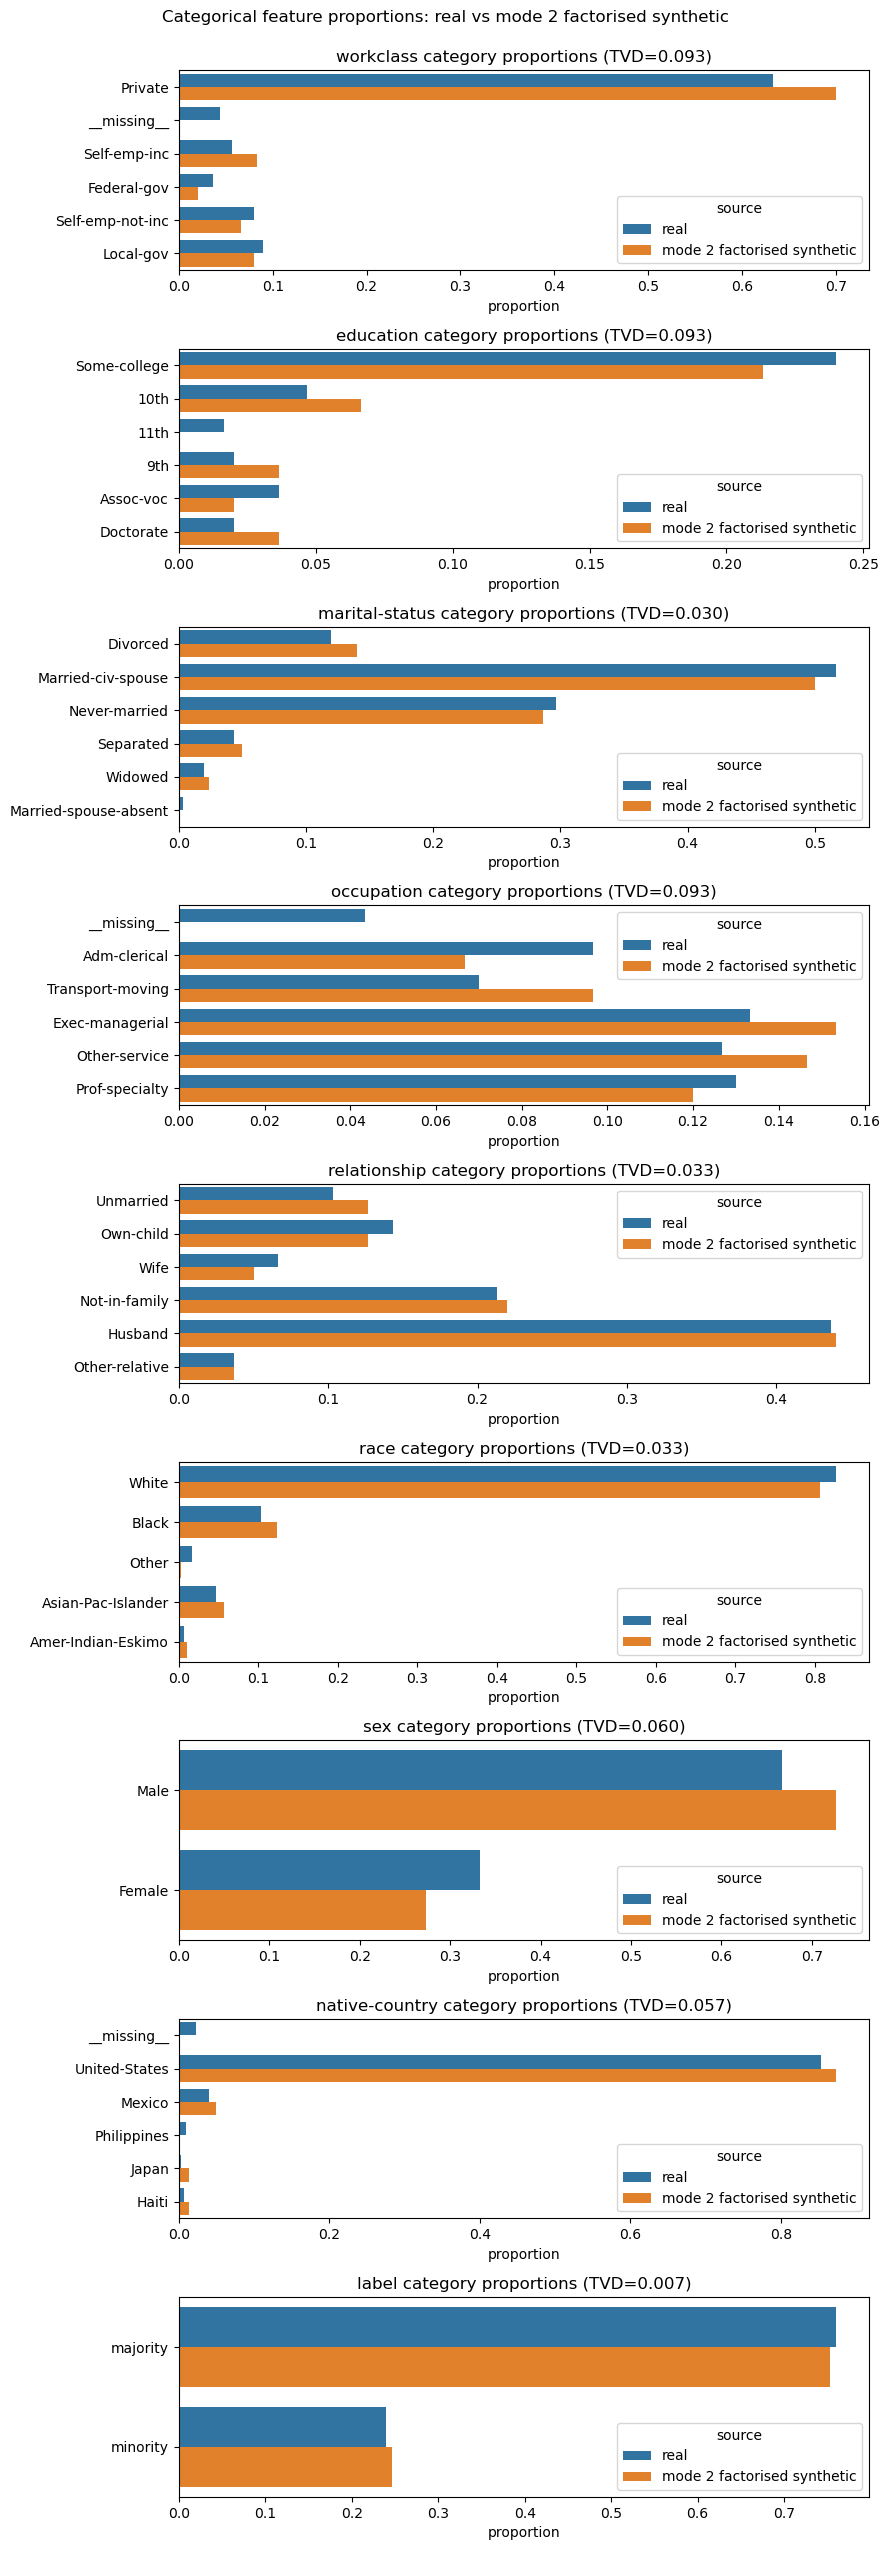

In [7]:
mode2_plain = run_dataset_synthesis_diagnostics(
    df,
    columns=columns,
    mode=2,
    capacity=CAPACITY,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    feature_n_jobs=FEATURE_N_JOBS,
    privacy_filter=None,
    label="mode 2 factorised synthetic",
)

display(mode2_plain["summary"].style.set_caption("Mode 2 summary"))
display(
    mode2_plain["categorical_summary"].sort_values("total_variation_distance", ascending=False)
    .style.format({"total_variation_distance": "{:.3f}"})
    .set_caption("Mode 2 categorical summary")
)


## Mode 2: factorised with privacy filtering

Nearest-neighbor ambiguity filtering is enabled for this run.

,quantity,value
0,mode,2
1,privacy_filter,True
2,real_rows,300
3,synthetic_rows,300
4,columns_match,True


,feature,total_variation_distance,n_categories
3,occupation,0.340,13
1,education,0.207,16
4,relationship,0.153,6
0,workclass,0.127,7
2,marital-status,0.113,6
5,race,0.090,5
7,native-country,0.077,22
8,label,0.053,2
6,sex,0.010,2


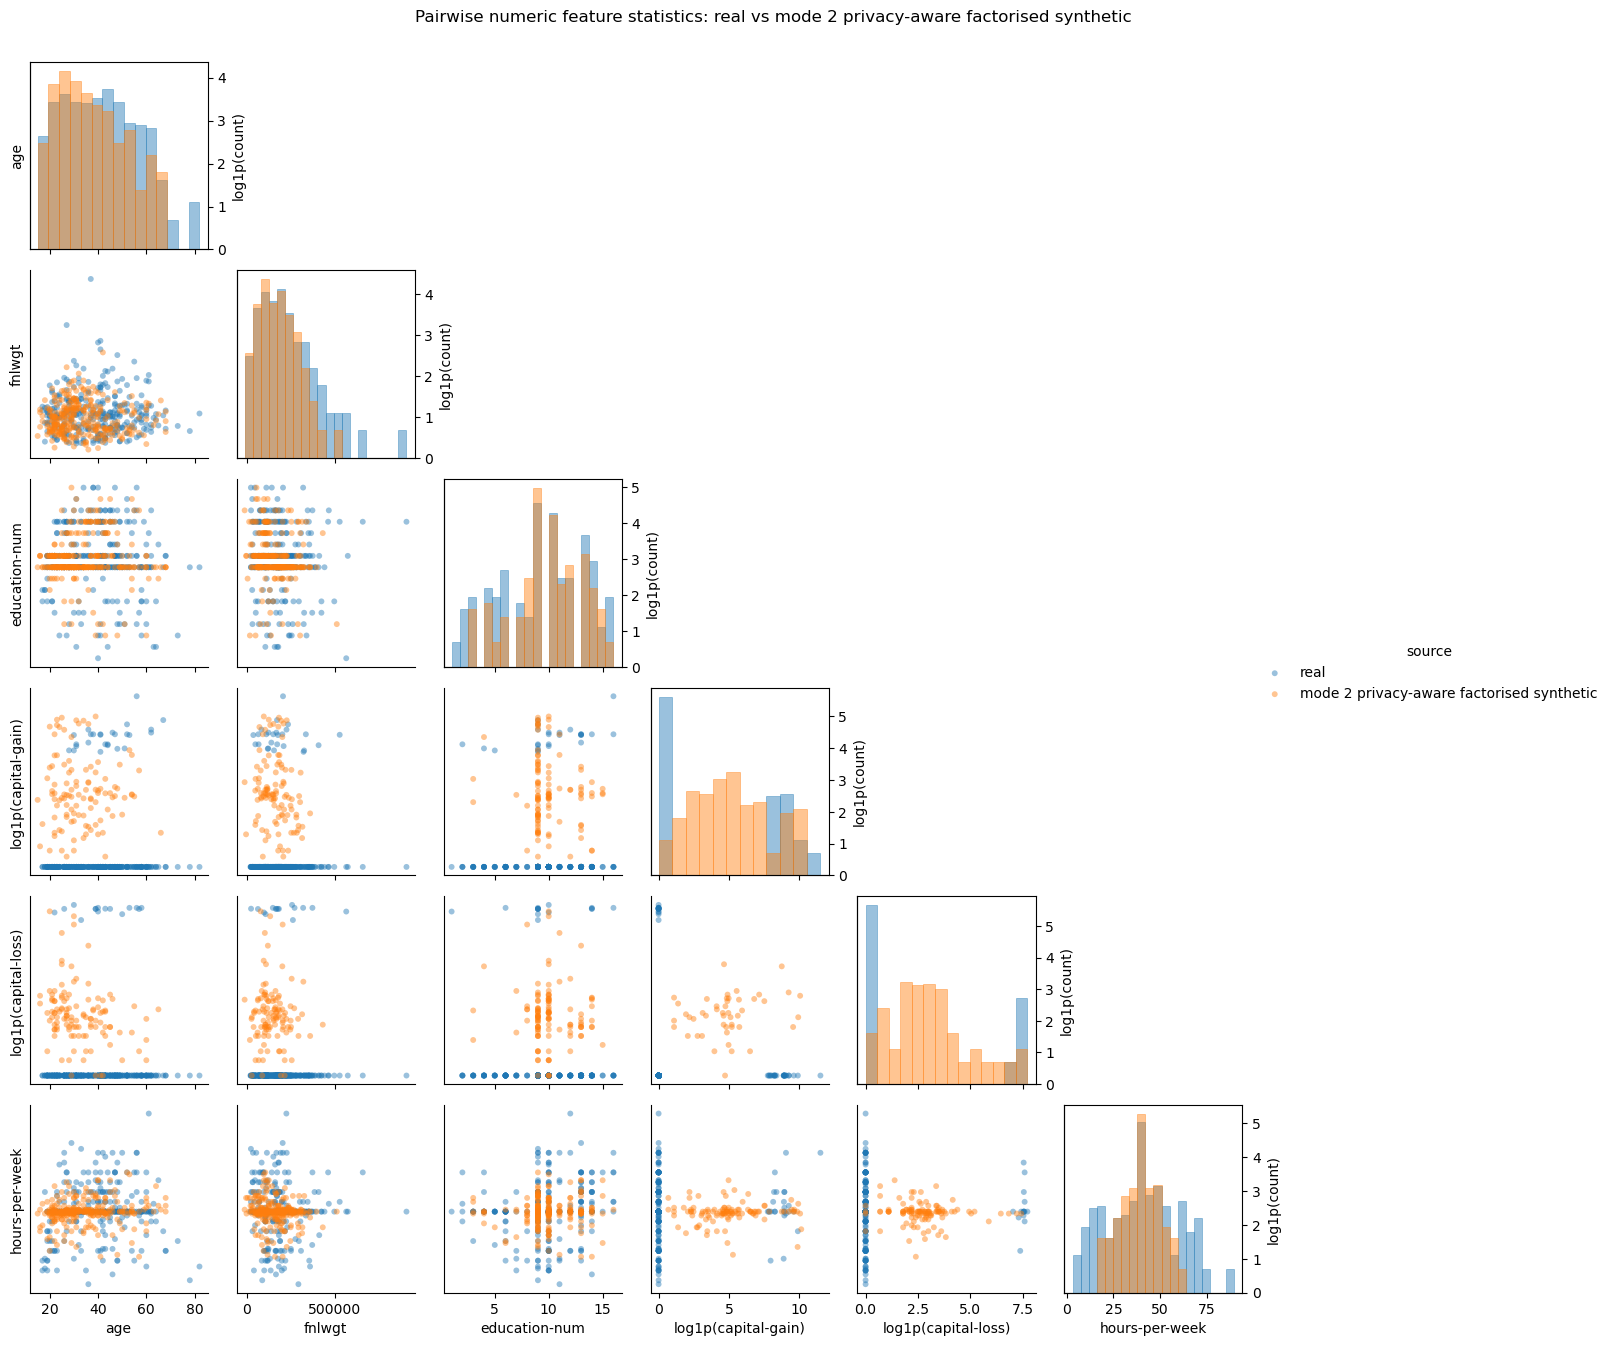

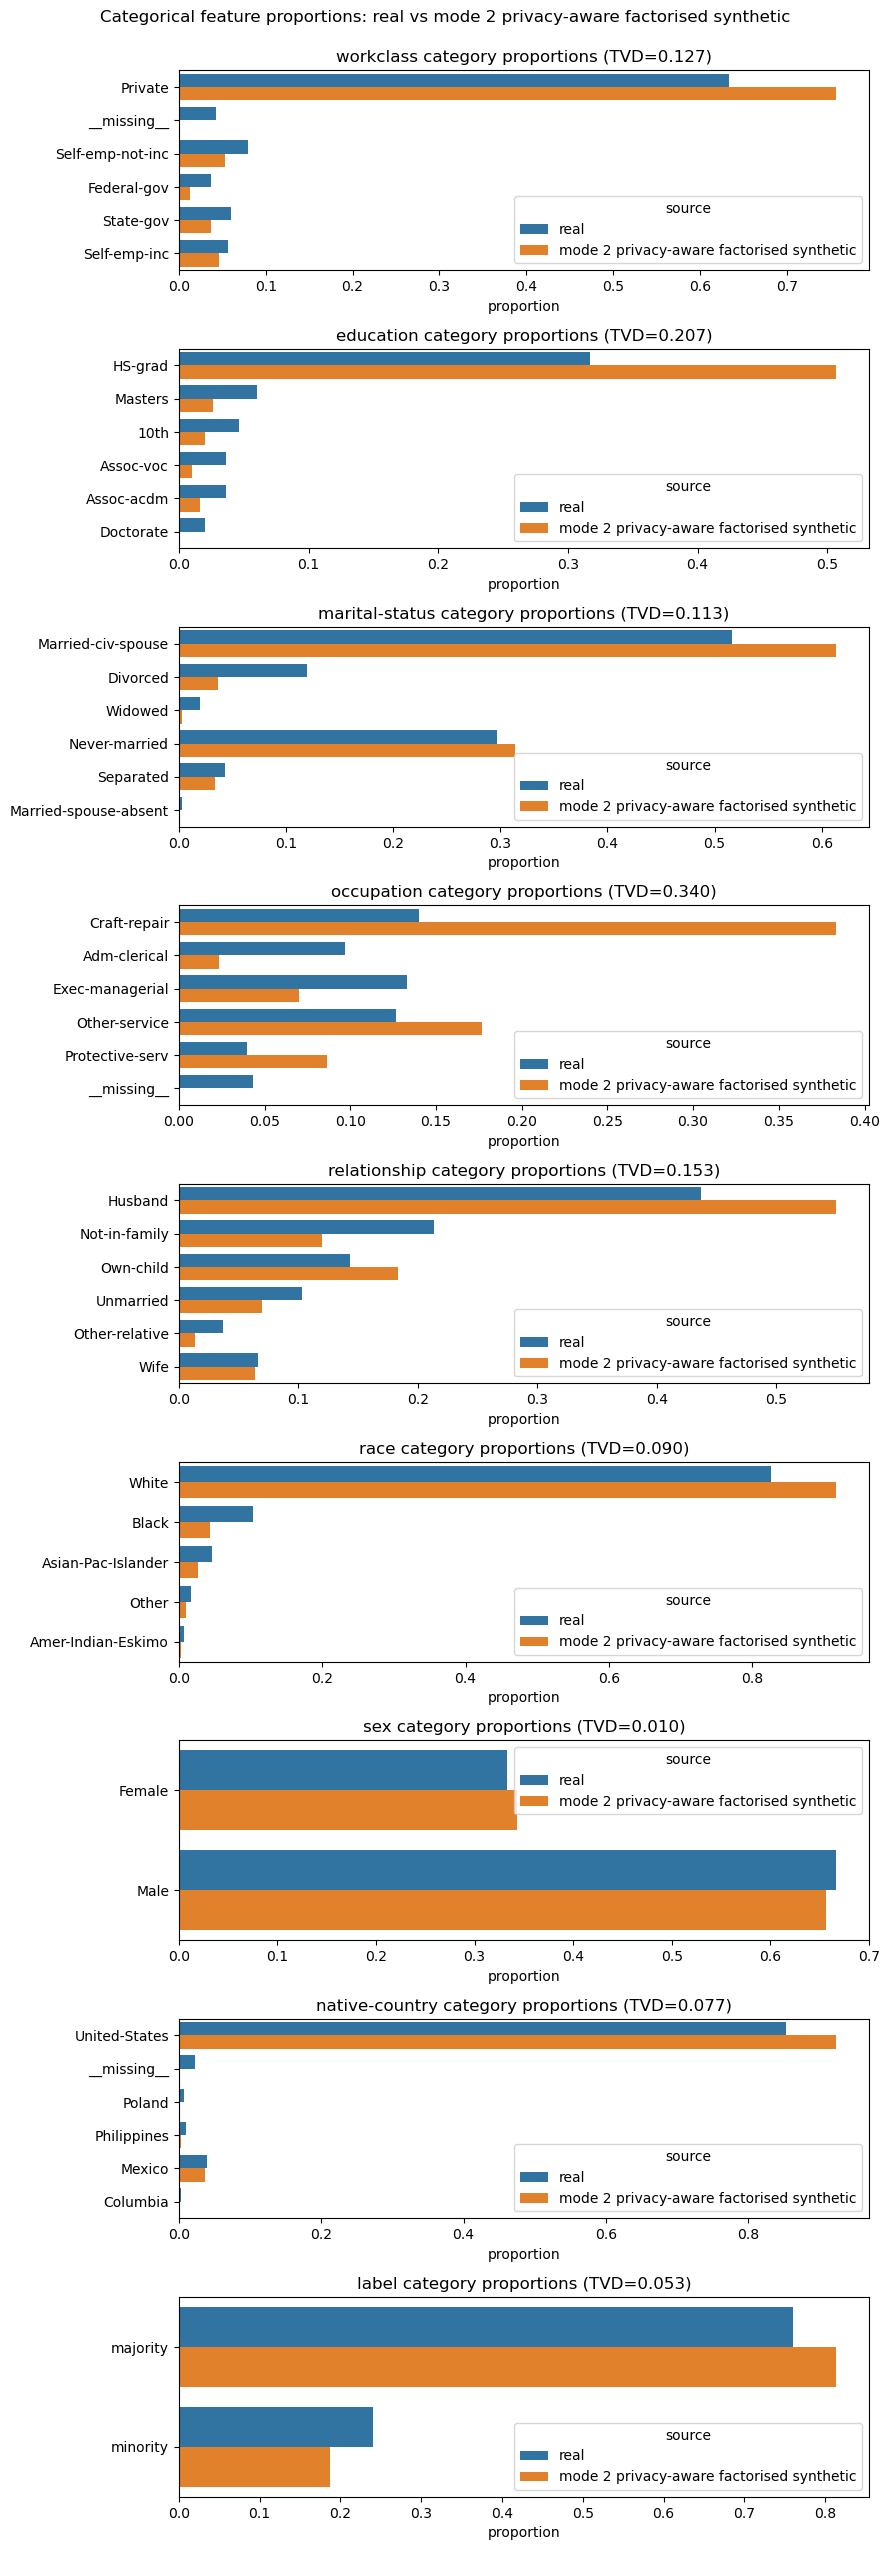

In [8]:
mode2_private = run_dataset_synthesis_diagnostics(
    df,
    columns=columns,
    mode=2,
    capacity=CAPACITY,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    feature_n_jobs=FEATURE_N_JOBS,
    privacy_filter=PRIVACY_FILTER,
    label="mode 2 privacy-aware factorised synthetic",
)

display(mode2_private["summary"].style.set_caption("Mode 2 privacy-aware summary"))
display(
    mode2_private["categorical_summary"].sort_values("total_variation_distance", ascending=False)
    .style.format({"total_variation_distance": "{:.3f}"})
    .set_caption("Mode 2 privacy-aware categorical summary")
)


## Mode 3: joint

This run uses the mode without nearest-neighbor ambiguity filtering.

,quantity,value
0,mode,3
1,privacy_filter,False
2,real_rows,300
3,synthetic_rows,300
4,columns_match,True


,feature,total_variation_distance,n_categories
0,workclass,0.313,7
3,occupation,0.297,13
1,education,0.227,16
5,race,0.147,5
7,native-country,0.137,22
4,relationship,0.057,6
2,marital-status,0.023,6
6,sex,0.013,2
8,label,0.010,2


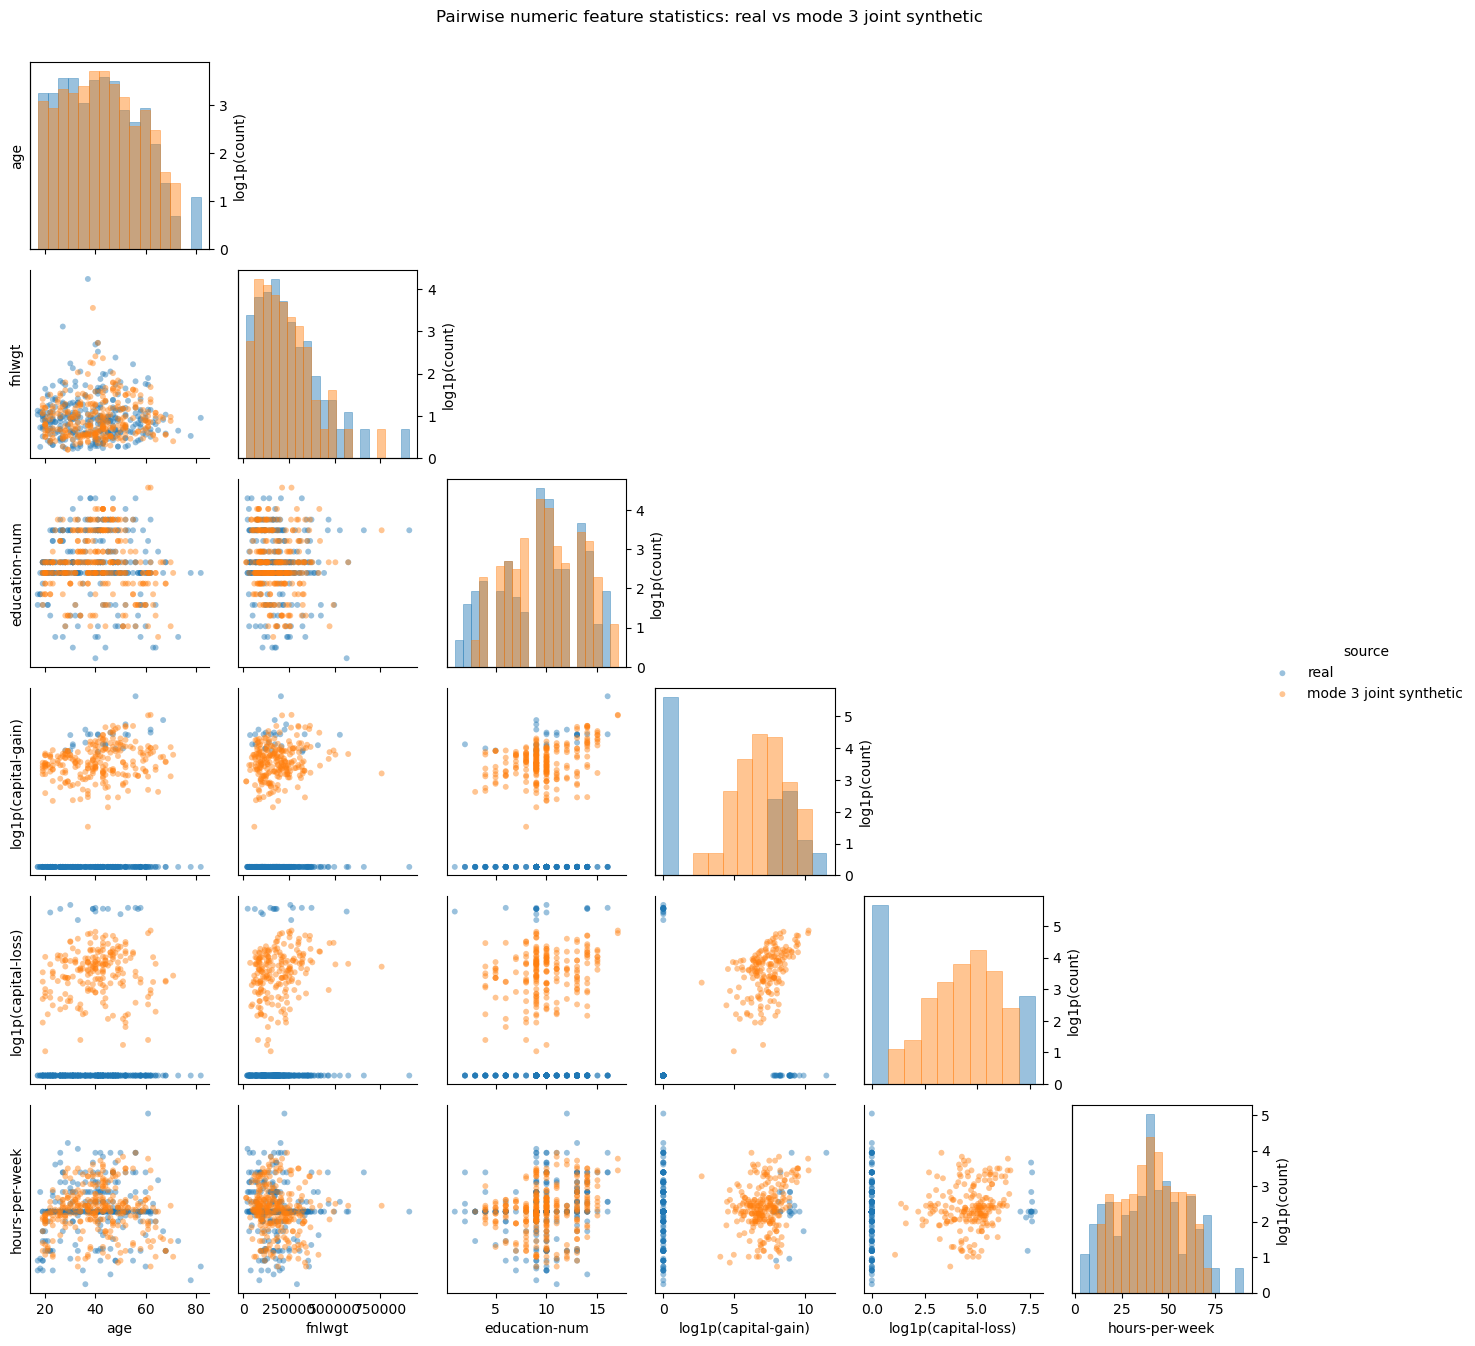

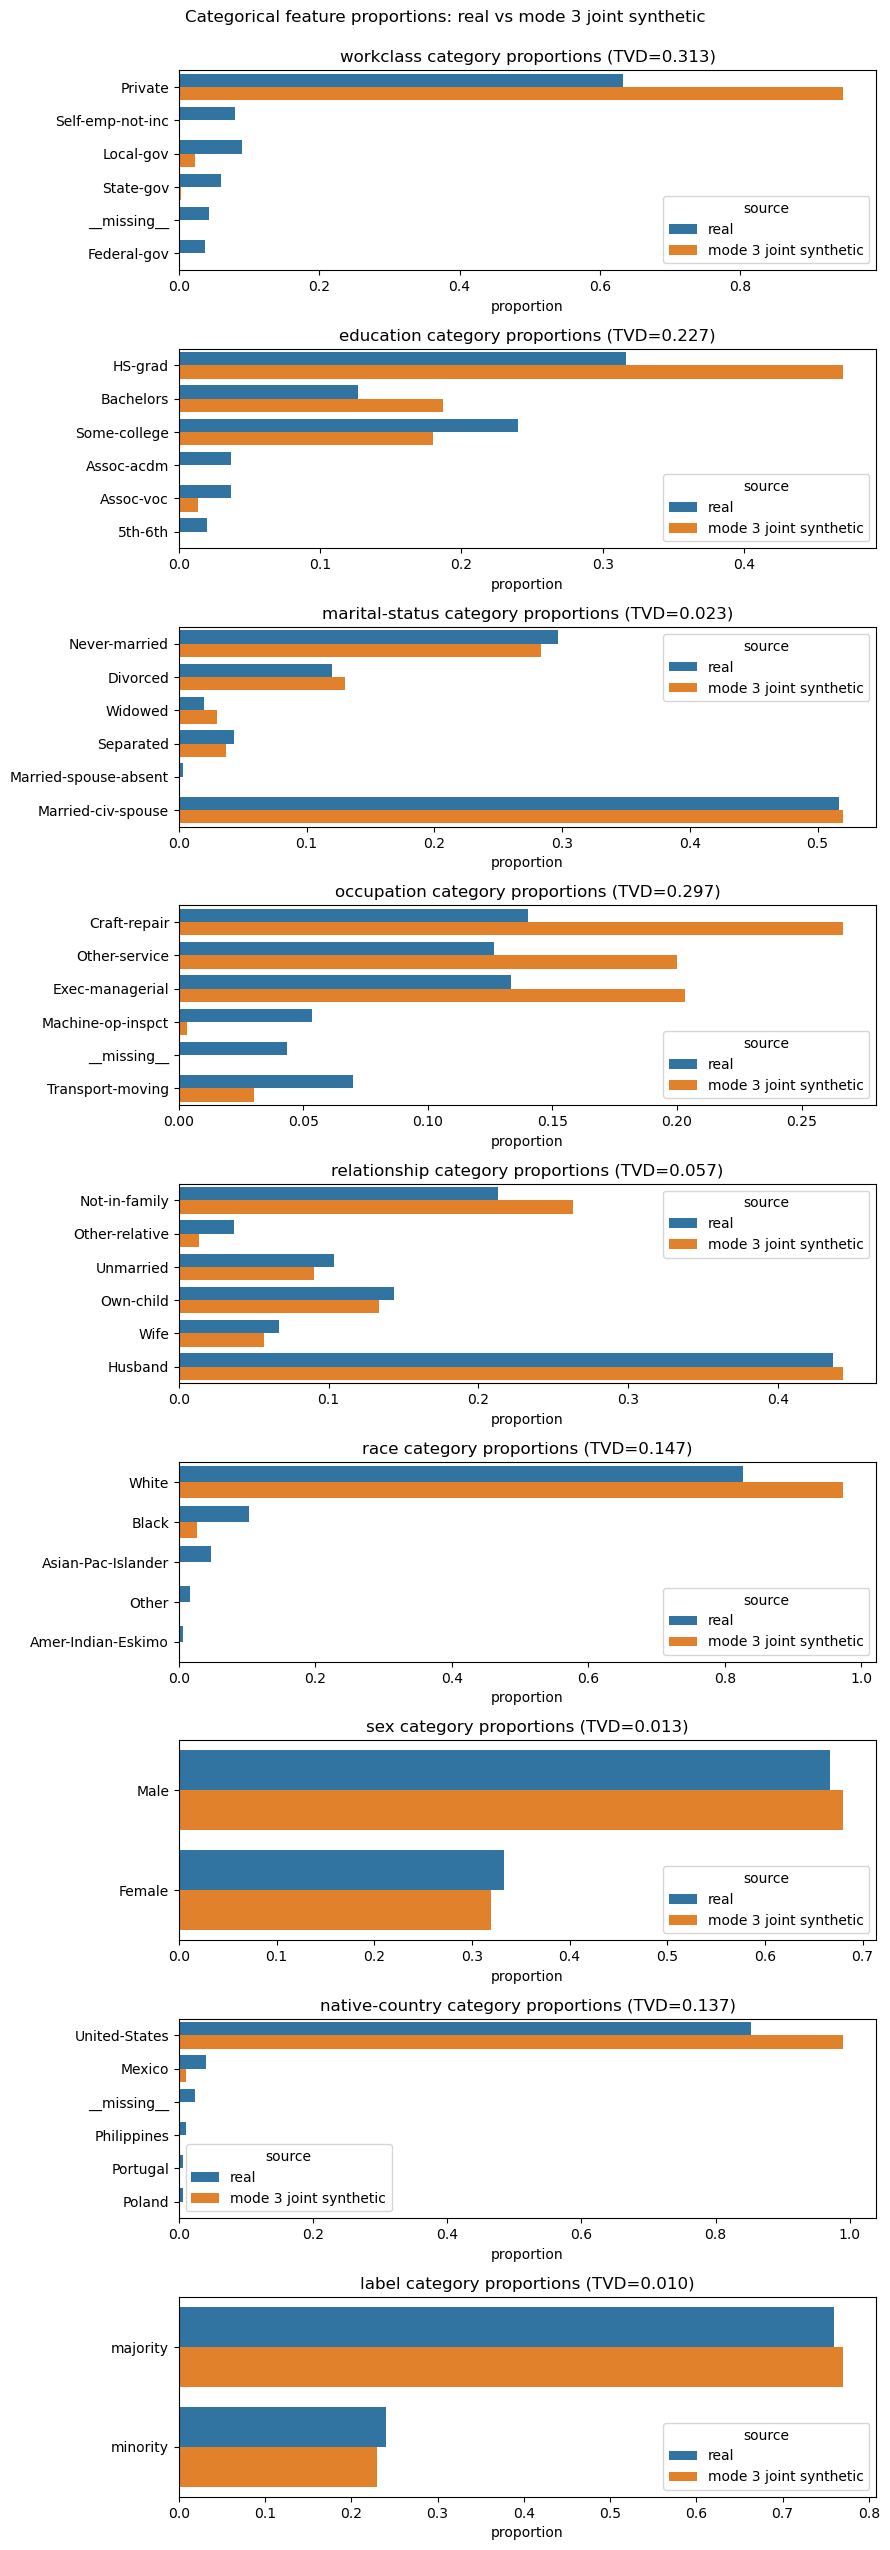

In [9]:
mode3_plain = run_dataset_synthesis_diagnostics(
    df,
    columns=columns,
    mode=3,
    capacity=CAPACITY,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    feature_n_jobs=FEATURE_N_JOBS,
    privacy_filter=None,
    label="mode 3 joint synthetic",
)

display(mode3_plain["summary"].style.set_caption("Mode 3 summary"))
display(
    mode3_plain["categorical_summary"].sort_values("total_variation_distance", ascending=False)
    .style.format({"total_variation_distance": "{:.3f}"})
    .set_caption("Mode 3 categorical summary")
)


## Mode 3: joint with privacy filtering

Nearest-neighbor ambiguity filtering is enabled for this run.

,quantity,value
0,mode,3
1,privacy_filter,True
2,real_rows,300
3,synthetic_rows,300
4,columns_match,True


,feature,total_variation_distance,n_categories
3,occupation,0.453,13
0,workclass,0.317,7
1,education,0.283,16
4,relationship,0.180,6
5,race,0.170,5
2,marital-status,0.150,6
7,native-country,0.147,22
8,label,0.080,2
6,sex,0.010,2


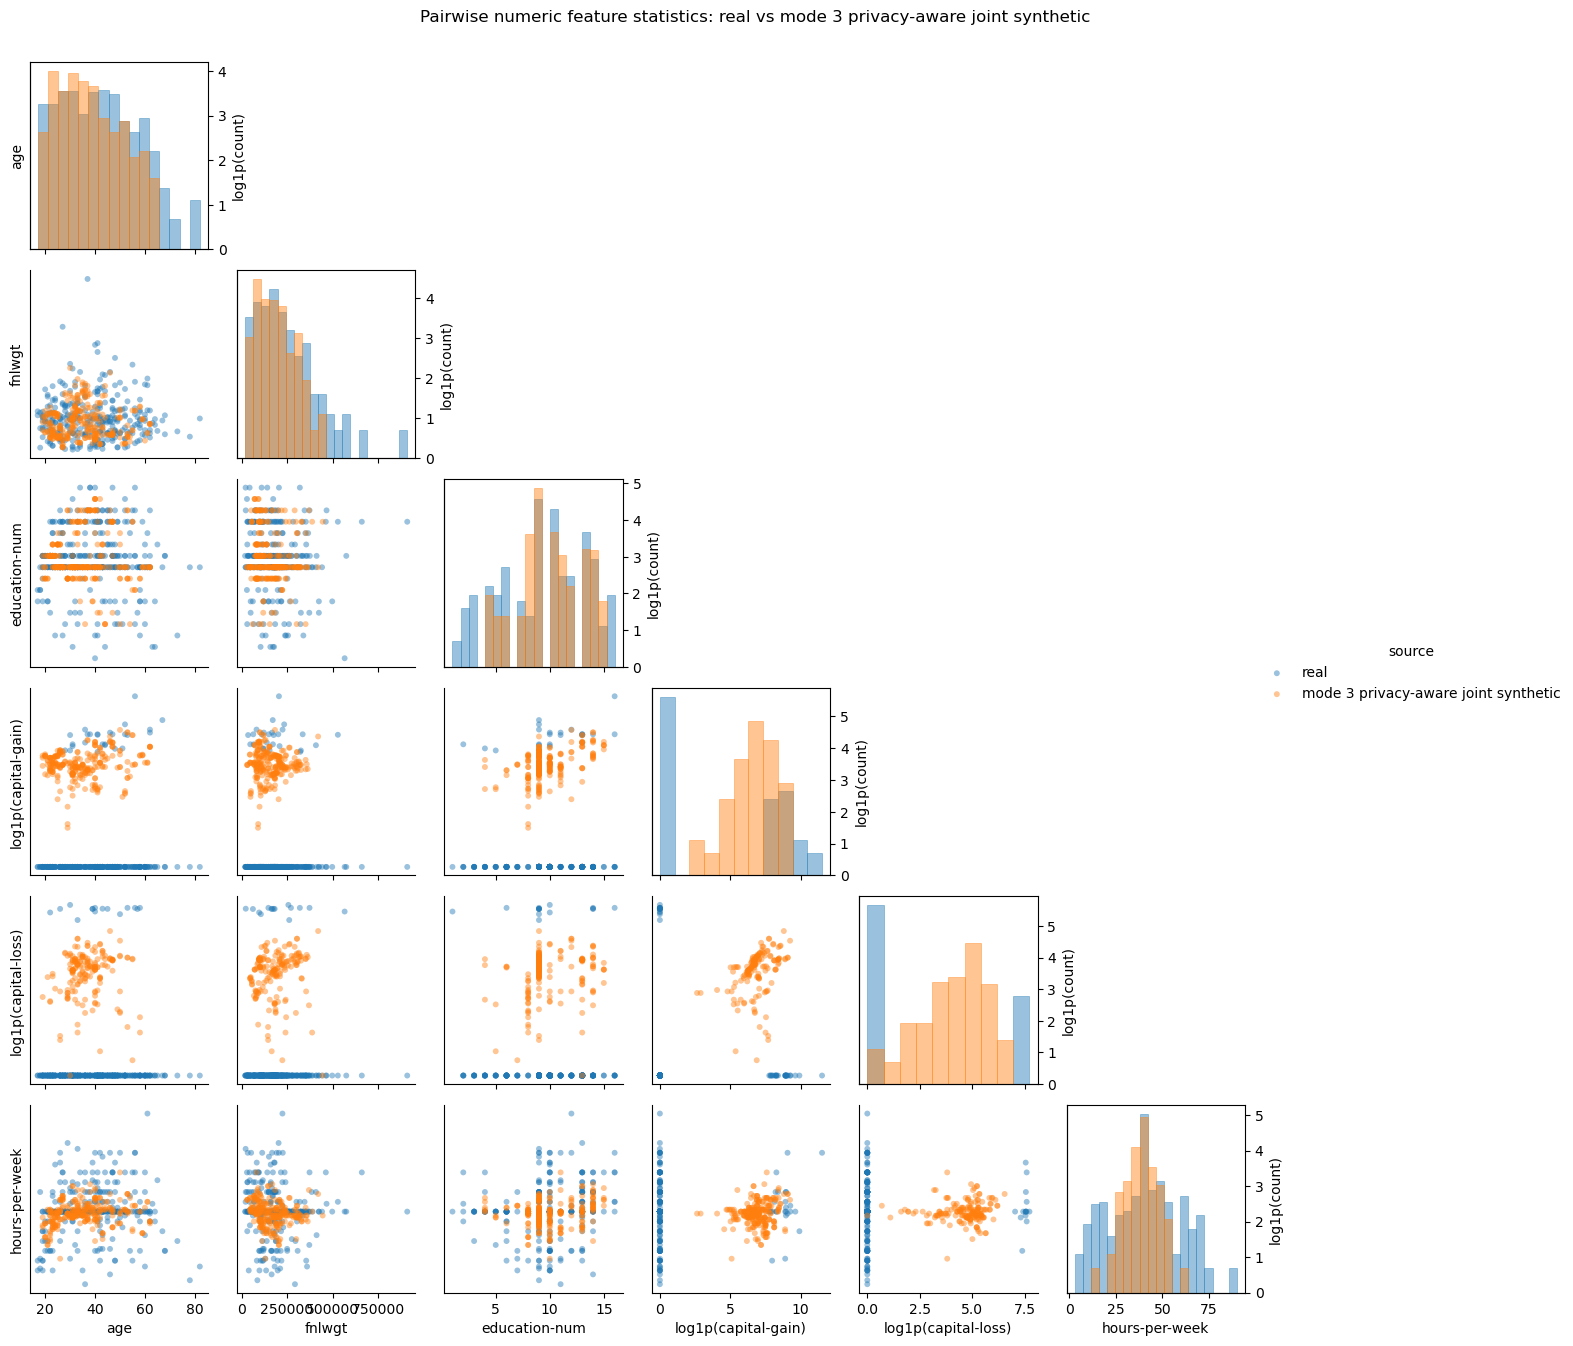

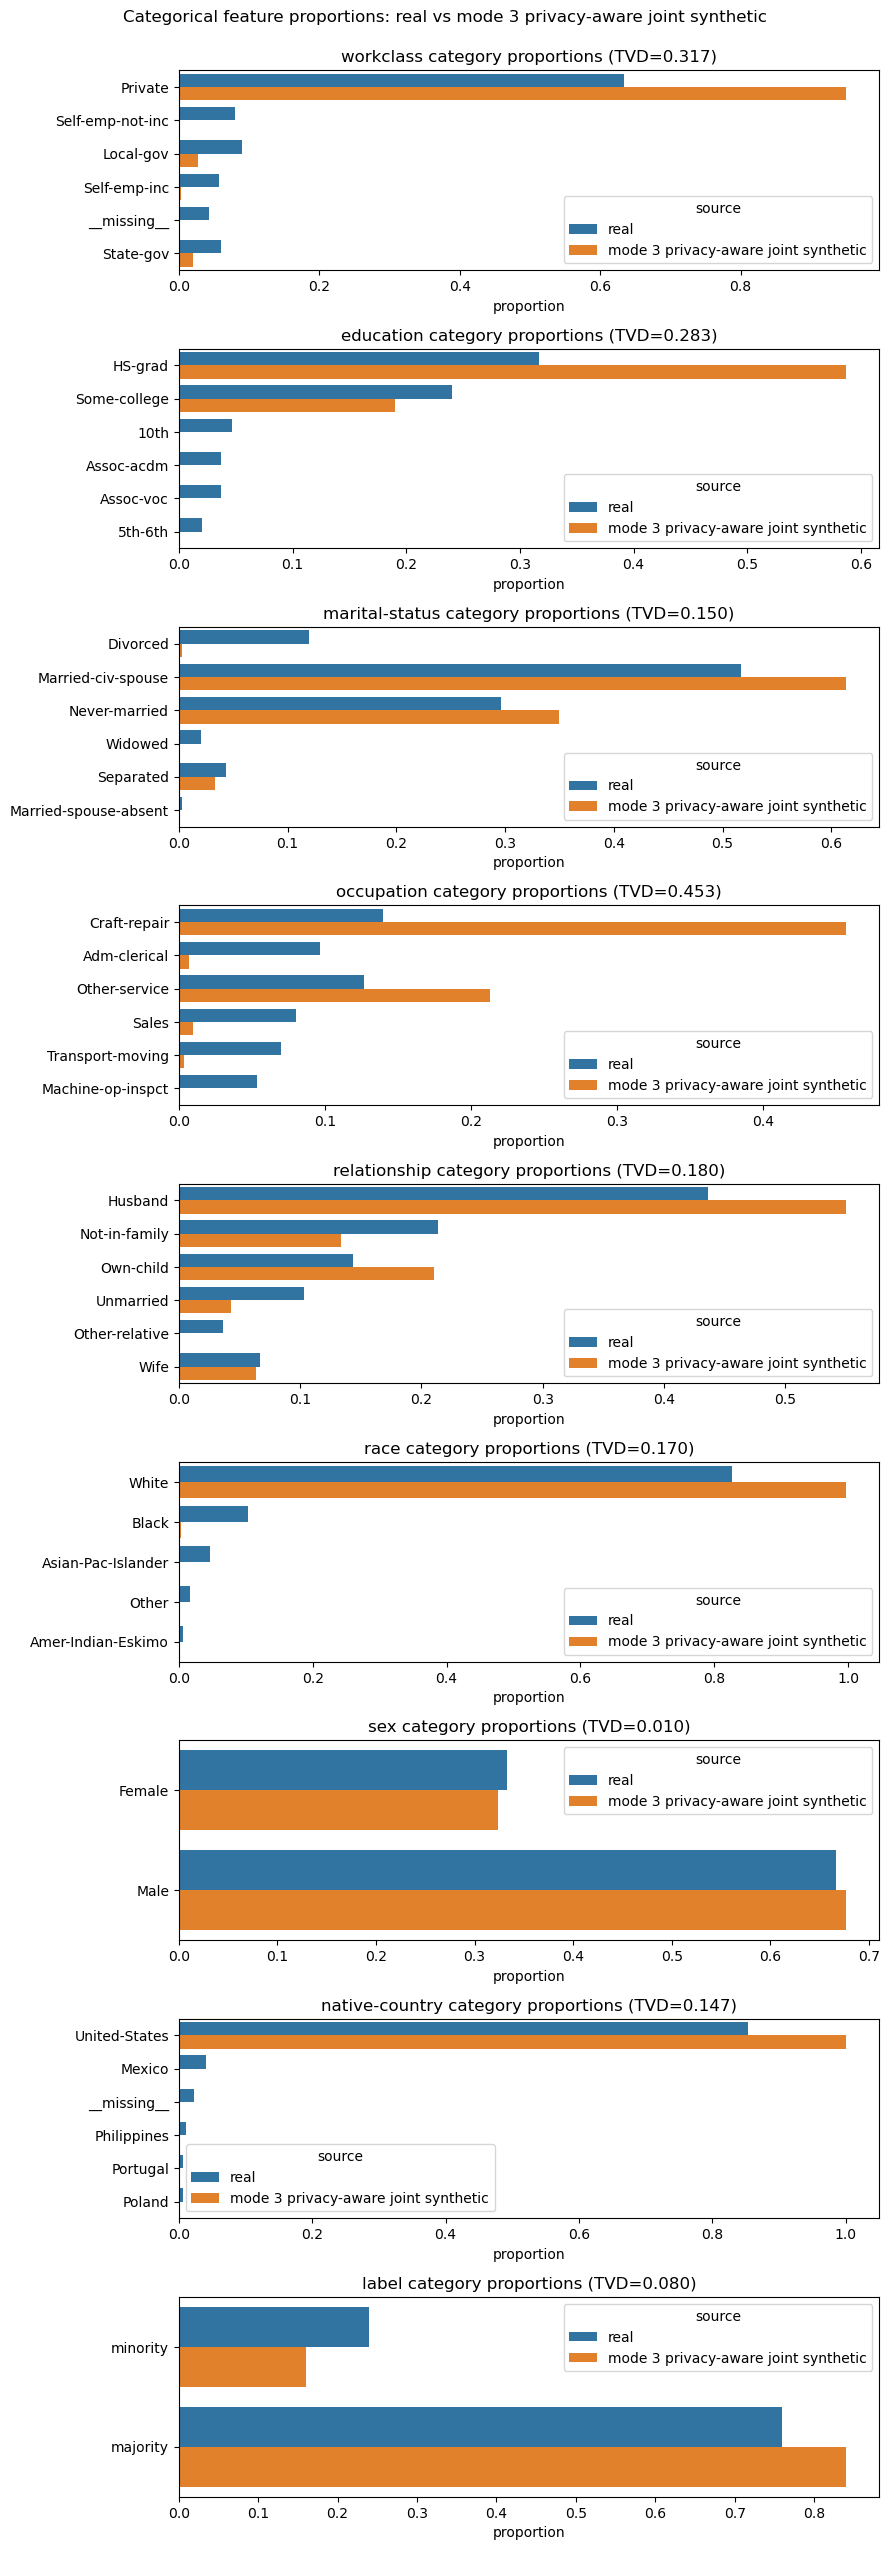

In [10]:
mode3_private = run_dataset_synthesis_diagnostics(
    df,
    columns=columns,
    mode=3,
    capacity=CAPACITY,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    feature_n_jobs=FEATURE_N_JOBS,
    privacy_filter=PRIVACY_FILTER,
    label="mode 3 privacy-aware joint synthetic",
)

display(mode3_private["summary"].style.set_caption("Mode 3 privacy-aware summary"))
display(
    mode3_private["categorical_summary"].sort_values("total_variation_distance", ascending=False)
    .style.format({"total_variation_distance": "{:.3f}"})
    .set_caption("Mode 3 privacy-aware categorical summary")
)
